# XLEAP scraping

# Init

In [30]:
print("hello world 4")

hello world 4


In [31]:
%matplotlib inline
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches
import numpy as np
import scipy.integrate as sint
import scipy.io as sio
import scipy.optimize as sopt
from scipy import signal as ssig
from scipy.stats import gaussian_kde
import epics
import subprocess 
from scipy.interpolate import interp1d

import pandas as pd
import itertools
import shutil 
from IPython import display
from IPython.utils import io
import scipy.interpolate as sinterp
from scipy.ndimage import gaussian_filter

import time
import os
from shutil import copyfile
import sys
import pickle
import copy
import shlex
import glob
import meme.archive as archive
import meme.names

from datetime import datetime
from datetime import timedelta
from dateutil import tz
import matplotlib.dates as mdate

import h5py

import BeamMoment_Helpers as BMH
#sys.path.append("../")
#from genesis import genesis,analysis,bsub
#import seaborn as sns
#sns.set(font_scale=1)
#sns.set_style("white")

colorlist=['#982649', '#6BCAE2', '#72bda3', '#ed6a5a', '#533a71']
#fde74c
colorlist2=['#E2836A','#6a7ee2','#74e26a']
prop_cycle = plt.rcParams['axes.prop_cycle']
def_colors = prop_cycle.by_key()['color']

#folder info
basedir="/nfs/slac/g/lcls/matlab/data_prod/2022/2022-03/2022-03-29/"
#basedir="/u/ar/dcesar/DocStorage/LH_beamtime_Feb252021/"
workdir=basedir
#

#save info Load
savefolder="/u/ar/dcesar/documents/"
savestem='presentation.png'

if os.path.exists(workdir):
    print("workdir already exists")
else:
    try:
        os.mkdir(workdir); 
    except: 
        print("Can't make path")

workdir already exists


In [32]:
qe=1.60218e-19
me=9.10938e-31
c=299792458
hb=6.58e-16

In [33]:
# Some styuff from PyHogs for reading/using matlab info

def print_mat_nested(d, indent=0, nkeys=0):
    """Pretty print nested structures from .mat files   
    Inspired by: `StackOverflow <http://stackoverflow.com/questions/3229419/pretty-printing-nested-dictionaries-in-python>`_
    """
    
    # Subset dictionary to limit keys to print.  Only works on first level
    if nkeys>0:
        d = {k: d[k] for k in d.keys()[:nkeys]}  # Dictionary comprehension: limit to first nkeys keys.

    if isinstance(d, dict):
        for key, value in d.iteritems():         # iteritems loops through key, value pairs
            print('\t' * indent + 'Key: ' + str(key))
            print_mat_nested(value, indent+1)

    if isinstance(d,np.ndarray) and d.dtype.names is not None:  # Note: and short-circuits by default
        for n in d.dtype.names:    # This means it's a struct, it's bit of a kludge test.
            print( '\t' * indent + 'Field: ' + str(n))
            print_mat_nested(d[n], indent+1)

#print_mat_nested(matdata, nkeys=10)

def loadmat(filename):
    '''
    this function should be called instead of direct sio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    
    from: `StackOverflow <http://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries>`_
    '''
    data = sio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

def _check_keys(dict):
    '''
    checks if entries in dictionary are mat-objects. If yes
    todict is called to change them to nested dictionaries
    '''
    for key in dict:
        if isinstance(dict[key], sio.matlab.mio5_params.mat_struct):
            dict[key] = _todict(dict[key])
    return dict        

def _todict(matobj):
    '''
    A recursive function which constructs from matobjects nested dictionaries
    '''
    dict = {}
    for strg in matobj._fieldnames:
        elem = matobj.__dict__[strg]
        if isinstance(elem, sio.matlab.mio5_params.mat_struct): #matlab.mio5_params.mat_struct
            dict[strg] = _todict(elem)
        elif isinstance(elem,np.ndarray) or isinstance(elem,list):
            flat=np.ndarray.flatten(elem)
            if len(flat)>0:
                if isinstance(flat[0],sio.matlab.mio5_params.mat_struct):
                    dict[strg]=[];
                    #print(strg)
                    for ele in flat:
                        dict[strg].append(_todict(ele)) 
                    dict[strg]=np.reshape(np.asarray(dict[strg]),np.shape(elem))
                else:
                    dict[strg] = elem
            else:
                dict[strg] = elem
        else:
            dict[strg] = elem
        
    return dict

#def _nested_lists_of_structs_todict(elem):
#if isinstance(elem[0],sio.matlab.mio5_params.mat_struct):
        

# matdata = loadmat(matfile)

# print_mat_nested(matdata, nkeys=6)

# Get lasing unds

In [34]:
f='/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-07/Und_GainLen_Scan--2021-07-07-132209.mat'

In [35]:
datere=re.search('--([0-9]*)-([0-9]*)-([0-9]*)-([0-9]*)',f)
ft=datetime(int(datere.group(1)),int(datere.group(2)),int(datere.group(3)),int(datere.group(4)[0:2]),int(datere.group(4)[2:4]),int(datere.group(4)[4:6]))
energy=np.mean(meme.archive.get('BEND:DMPS:400:BACT', from_time=ft,to_time=ft+timedelta(seconds=3))['values'])
energy

np.float64(5.000001304260174)

In [36]:
model=meme.model.Model('SC_SXR')

2026-04-27T11:44:52.183202747 ERR pvxs.client.dup Duplicate PV name BMAD:SYS0:1:SC_SXR:LIVE:TWISS from 134.79.151.36:36759 and 134.79.151.21:34077


In [37]:
# check for KAct
vals = meme.names.list_pvs('USEG:UNDS:2150:%')
[x for x in vals if 'Act' in x][:100]


2026-04-27T11:44:52.204515097 WARN pvxs.client.io Server 134.79.151.36:42467 no supported auth.  try to force 'anonymous'


['USEG:UNDS:2150:ActiveMode',
 'USEG:UNDS:2150:DS:PotExtensionAct',
 'USEG:UNDS:2150:DS:VAct',
 'USEG:UNDS:2150:DSKAct',
 'USEG:UNDS:2150:GapAct',
 'USEG:UNDS:2150:GapActDP',
 'USEG:UNDS:2150:GapActFP',
 'USEG:UNDS:2150:GapActSV',
 'USEG:UNDS:2150:KAct',
 'USEG:UNDS:2150:OffsetAct',
 'USEG:UNDS:2150:OffsetActDP',
 'USEG:UNDS:2150:OffsetActFP',
 'USEG:UNDS:2150:OffsetActSV',
 'USEG:UNDS:2150:SlopeAct',
 'USEG:UNDS:2150:SlopeActDP',
 'USEG:UNDS:2150:SlopeActFP',
 'USEG:UNDS:2150:SlopeActSV',
 'USEG:UNDS:2150:TaperAct',
 'USEG:UNDS:2150:TaperActDP',
 'USEG:UNDS:2150:TaperActFP',
 'USEG:UNDS:2150:TaperActSV',
 'USEG:UNDS:2150:US:PotExtensionAct',
 'USEG:UNDS:2150:US:VAct']

In [38]:
# List all undulators
vals = meme.names.list_pvs('USEG:UNDS:%:KAct')
# { v for v in vals}
vals

['USEG:UNDS:2150:KAct',
 'USEG:UNDS:2250:KAct',
 'USEG:UNDS:2350:KAct',
 'USEG:UNDS:2450:KAct',
 'USEG:UNDS:2550:KAct',
 'USEG:UNDS:2650:KAct',
 'USEG:UNDS:2750:KAct',
 'USEG:UNDS:2850:KAct',
 'USEG:UNDS:2950:KAct',
 'USEG:UNDS:3050:KAct',
 'USEG:UNDS:3150:KAct',
 'USEG:UNDS:3250:KAct',
 'USEG:UNDS:3350:KAct',
 'USEG:UNDS:3450:KAct',
 'USEG:UNDS:3650:KAct',
 'USEG:UNDS:3750:KAct',
 'USEG:UNDS:3850:KAct',
 'USEG:UNDS:3950:KAct',
 'USEG:UNDS:4050:KAct',
 'USEG:UNDS:4150:KAct',
 'USEG:UNDS:4250:KAct',
 'USEG:UNDS:4350:KAct',
 'USEG:UNDS:4450:KAct',
 'USEG:UNDS:4550:KAct',
 'USEG:UNDS:4650:KAct',
 'USEG:UNDS:4750:KAct']

In [39]:
KAct=meme.names.list_pvs('USEG:UNDS:%:KAct')
PVs=KAct
archive_data=meme.archive.get(PVs, from_time=ft,to_time=ft+timedelta(seconds=3))
archive_data = [a for a in archive_data if a is not None]
Ks=np.array([x['value']['value']['values'][-1] for x in archive_data])
und_cells=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])
Ks

Request for PV USEG:UNDS:2350:KAct failed due to error: list index out of rangeRequest for PV USEG:UNDS:2450:KAct failed due to error: list index out of range
Request for PV USEG:UNDS:2250:KAct failed due to error: list index out of range

Request for PV USEG:UNDS:2550:KAct failed due to error: list index out of range
Request for PV USEG:UNDS:2150:KAct failed due to error: list index out of range


array([4.72339862, 4.72340481, 4.7235172 , 4.72382714, 4.72285934,
       4.72827555, 4.73382819, 4.73875293, 4.74318628, 5.27863816,
       4.11330313, 2.96682816, 4.66944499, 2.85092492, 3.48395881,
       5.26974856, 3.20964386, 4.61020356, 4.41303889, 3.07966786,
       3.8427564 ])

In [40]:
(np.abs(np.diff([1,1.5,1.51,1.52,1.53,1.53,1.67,1.67],prepend=-1))<1e-1)|(np.abs(np.diff([1,1.5,1.51,1.52,1.53,1.53,1.67,1.67],append=-1))<1e-1)

array([False,  True,  True,  True,  True,  True,  True,  True])

In [41]:
~(np.abs(np.diff([1,1.5,1.51,1.52,1.53,1.53,1.67,1.67],prepend=-1))<1e-1)&(np.abs(np.diff([1,1.5,1.51,1.52,1.53,1.53,1.67,1.67],append=-1))<1e-1)

array([False,  True, False, False, False, False,  True, False])

In [42]:
from scipy.ndimage import binary_erosion
def lasing_und(Ks,und_cells,kdist=3e-2):
    kidxs=np.argsort(Ks)
    ksort=Ks[kidxs]
    mask=(np.abs(np.diff(ksort,prepend=-1))/ksort<kdist)|(np.abs(np.diff(ksort,append=-1))/ksort<kdist) #alls undulators who have another undulator near them in K
    fund_idxs=kidxs[mask] #fund is for fundamental, to be distinguished from harmonics (considered later)
    
    # We should throw away any "group" of Ks with less than 5 undulators in it.
    kmin_idx=np.where(~(np.abs(np.diff(ksort,prepend=-1))/ksort<kdist)&(np.abs(np.diff(ksort,append=-1))/ksort<kdist) )[0] #idx of the lowest K in "group" of close Ks.
    #print(ksort[kmin_idx])
    for  kmin,kmax in zip(kmin_idx, list(kmin_idx[1:])+[len(kidxs)]):
        if np.sum(mask[kmin:kmax])<6:
            mask[kmin:kmax]=0
    #print(ksort[mask])
    #print(und_cells[kidxs][mask])
    fund_idxs=kidxs[mask] #fund is for fundamental, to be distinguished from harmonics (considered later)
    
    lasing_cells=und_cells[fund_idxs]
    lasing_ks=Ks[fund_idxs]
    idxs=np.argsort(lasing_cells)
    lasing_cells=lasing_cells[idxs]
    lasing_ks=lasing_ks[idxs]
    
    ## force 2 wihtin 3 unds 
    #mask=binary_erosion()
    
    return lasing_cells,lasing_ks

lasing_und(Ks,und_cells,kdist=1e-2)
# lasing_und(Ks,unds,kdist=1e-2)

(array([26., 27., 28., 29., 30., 31., 32., 33., 34.]),
 array([4.72339862, 4.72340481, 4.7235172 , 4.72382714, 4.72285934,
        4.72827555, 4.73382819, 4.73875293, 4.74318628]))

In [43]:
kidxs=np.argsort(Ks)
ksort=Ks[kidxs]
np.abs(np.diff(ksort,prepend=-1))/ksort

array([1.35076336e+00, 3.90663817e-02, 3.66402152e-02, 4.04954603e-02,
       7.87365652e-02, 9.33698498e-02, 6.57735932e-02, 6.79204892e-02,
       4.27670205e-02, 1.26870395e-02, 1.13097484e-02, 1.14171025e-04,
       1.31106570e-06, 2.37936992e-05, 6.56118569e-05, 9.40810205e-04,
       1.17297117e-03, 1.03924819e-03, 9.34677063e-04, 9.99217086e-02,
       1.68406947e-03])

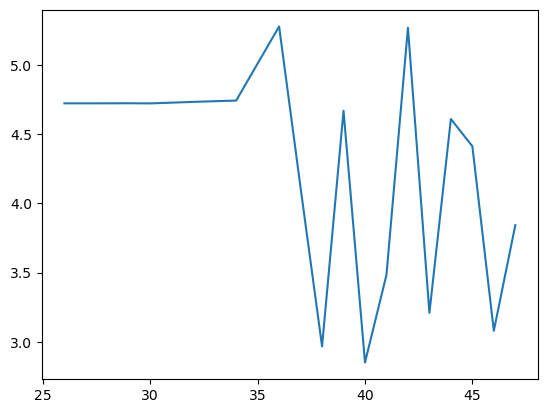

In [44]:
ax=plt.gca()
ax.plot(und_cells,Ks)

In [45]:
Ks

array([4.72339862, 4.72340481, 4.7235172 , 4.72382714, 4.72285934,
       4.72827555, 4.73382819, 4.73875293, 4.74318628, 5.27863816,
       4.11330313, 2.96682816, 4.66944499, 2.85092492, 3.48395881,
       5.26974856, 3.20964386, 4.61020356, 4.41303889, 3.07966786,
       3.8427564 ])

In [46]:
# np.diff(data['K_orig'][0,:])

In [47]:
np.diff(Ks)

array([ 6.19269404e-06,  1.12389947e-04,  3.09939070e-04, -9.67796973e-04,
        5.41620686e-03,  5.55264398e-03,  4.92474040e-03,  4.43334742e-03,
        5.35451873e-01, -1.16533503e+00, -1.14647496e+00,  1.70261683e+00,
       -1.81852007e+00,  6.33033890e-01,  1.78578975e+00, -2.06010470e+00,
        1.40055970e+00, -1.97164670e-01, -1.33337103e+00,  7.63088544e-01])

## Look for gain length plots

In [48]:
spec_dir="/nfs/slac/g/lcls/matlab/data_prod/2022/2022-08/2022-08-16/"
glscans=glob.glob(spec_dir+'*Und_GainLen*')
glscans

['/nfs/slac/g/lcls/matlab/data_prod/2022/2022-08/2022-08-16/Und_GainLen_Scan--2022-08-16-225447.mat']

In [49]:
gl_2022_files=subprocess.run(["find /nfs/slac/g/lcls/matlab/data_prod/2022/*/*/*Und_GainLen* -type f"],shell=True, capture_output=True).stdout.decode("utf-8").split('\n')[:-1]
gl_2022_files

['/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-17/Und_GainLen_Scan--2022-02-17-001638.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-17/Und_GainLen_Scan--2022-02-17-041415.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-23/Und_GainLen_Scan--2022-02-23-231540.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-24/Und_GainLen_Scan--2022-02-24-005919.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-24/Und_GainLen_Scan--2022-02-24-012753.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-24/Und_GainLen_Scan--2022-02-24-022827.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-04/2022-04-19/Und_GainLen_Scan--2022-04-19-131749.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-04/2022-04-19/Und_GainLen_Scan--2022-04-19-132618.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-04/2022-04-19/Und_GainLen_Scan--2022-04-19-135518.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2022/2022-04/2022-04-25/Und_GainLen_Scan--2022

2/24 is Reamplification with Tais(?) 

4/19 is ChemRixs VLS and shows effect of increasing taper

4/25 simmilar to 4/19, but maybe less nice?

In [50]:
gl_2021_files=subprocess.run(["find /nfs/slac/g/lcls/matlab/data_prod/2021/*/*/*Und_GainLen* -type f"],shell=True, capture_output=True).stdout.decode("utf-8").split('\n')[:-1]
gl_2021_files

['/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-07/Und_GainLen_Scan--2021-07-07-132209.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-07/Und_GainLen_Scan--2021-07-07-181453.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-07/Und_GainLen_Scan--2021-07-07-201441.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-08/Und_GainLen_Scan--2021-07-08-083617.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-08/Und_GainLen_Scan--2021-07-08-084104.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-08/Und_GainLen_Scan--2021-07-08-084617.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-09/Und_GainLen_Scan--2021-07-09-230015.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-10/Und_GainLen_Scan--2021-07-10-062304.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-10/Und_GainLen_Scan--2021-07-10-065443.mat',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-11/Und_GainLen_Scan--2021

7/7,7/8 are reamplifcation. There are some gl of first stage, but mostly looking at second.

In [53]:
print(len(gl_2021_files),len(gl_2022_files))

21 25


In [54]:
# data['cells']

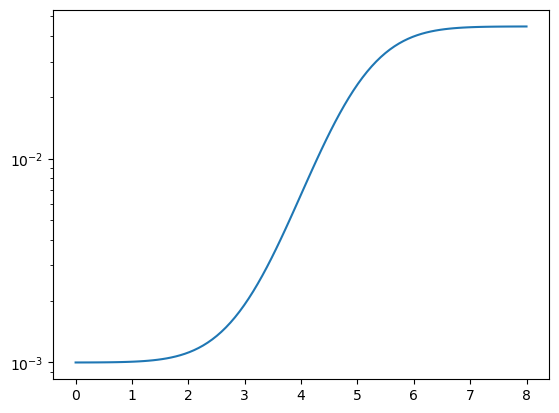

In [57]:
from scipy.optimize import minimize
from scipy.special import erf

def expfit(c,xs):
    lin=0
    gl=(1+erf((xs-c[1])/c[0])*c[0])*np.sqrt(np.pi)/2
    exp=c[3]*np.exp(gl/c[2])/np.min(np.exp(gl/c[2]))
    return lin+exp
def objective(c,xs,ys,cmin):
    return np.sum(np.abs(ys-expfit(list(c)+[cmin],xs))**2/ys**2)
ax=plt.gca()
abscissa=np.linspace(0,8,100)
ax.semilogy(abscissa,expfit((1.5,4,0.7,1e-3),abscissa))
plt.show()

def fit_gain(data,cells):
    x0=(1.5,np.mean(cells),0.7)
    cells=cells#4+np.array(range(len(data)))
    sol=minimize(objective,x0=x0,args=(cells,data,min(data)))
    return sol['x']

In [58]:
# cells

In [60]:
# fit_gain(fom,cells)

Request for PV USEG:UNDS:2350:KAct failed due to error: list index out of range
Request for PV USEG:UNDS:2250:KAct failed due to error: list index out of range
Request for PV USEG:UNDS:2450:KAct failed due to error: list index out of range
Request for PV USEG:UNDS:2150:KAct failed due to error: list index out of range
Request for PV USEG:UNDS:2550:KAct failed due to error: list index out of range


TypeError: 'NoneType' object is not subscriptable

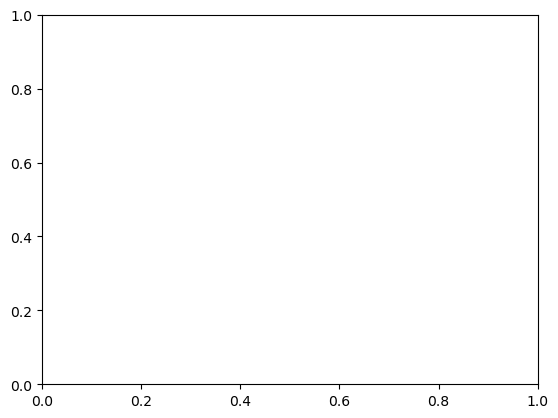

In [61]:
ax=plt.gca()
hws=[];
energies=[];
fits=[];
satlen=[];
klase=[];
dates=[];
usedfiles=[];

for ii,file in enumerate(gl_2021_files + gl_2022_files):
    datere=re.search('--([0-9]*)-([0-9]*)-([0-9]*)-([0-9]*)',file)
    ft=datetime(int(datere.group(1)),int(datere.group(2)),int(datere.group(3)),int(datere.group(4)[0:2]),int(datere.group(4)[2:4]),int(datere.group(4)[4:6]))
    energy=np.mean(meme.archive.get('BEND:DMPS:400:BACT', from_time=ft,to_time=ft+timedelta(seconds=3))['values'])
    
    try:
        archive_data=meme.archive.get(PVs, from_time=ft,to_time=ft+timedelta(seconds=3))
    except:
        try:
            archive_data=meme.archive.get(PVs, from_time=ft,to_time=ft+timedelta(seconds=3))
        except:
            archive_data=meme.archive.get(PVs, from_time=ft,to_time=ft+timedelta(seconds=3))
    Ks=np.array([x['value']['value']['values'][-1] for x in archive_data])
    unds=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])
    lasing_cells,lasing_ks=lasing_und(Ks,unds,kdist=1e-2)
    
    if h5py.is_hdf5(file):
        f = h5py.File(file, 'r')
        data=f['data']
        cells=data['cells'][:].flatten()
        nc=len(cells)
        idx=np.where(np.array(data['fom'].shape)==nc)[0][0]
        axes=list(range(len(data['fom'].shape)))
        axes.pop(idx)
        fom=np.median(data['fom'],axis=axes)
        fom=np.percentile(data['fom'],90,axis=axes)
        k=f['data']['K_orig'][0,-1]
        f.close()
    else:
        data=loadmat(file)['data']
        cells=data['cells'][:].flatten()
        nc=len(cells)
        idx=np.where(np.array(data['fom'].shape)==nc)[0][0]
        axes=list(range(len(data['fom'].shape)))
        axes.pop(idx)
        fom=np.median(data['fom'],axis=axes)
        fom=np.percentile(data['fom'],90,axis=axes)
        k=data['K_orig'][0,-1]
    if fom[0]>5e-3 or nc>12 or fom[-1]<8e-3 or nc<5:
        continue
    xlamd=0.039/(2*(energy*1000/0.511)**2)*(1+k**2/2)
    hw=1240e-9/xlamd
    color=cm.viridis((hw-250)/400)
    
    try:
        #union=np.union1d
        #
        mask=np.in1d(cells,lasing_cells)
        cells=cells[mask]
        fom=fom[mask]
        cellidx=[np.where(x==np.array(lasing_cells))[0][0] for x in cells]
    except:
        print('Failed to calc cellidx',ii,lasing_cells,cells)
    
    print(min(cellidx))
    ax.semilogy(cellidx,fom,'.--',color=color)      
    c=fit_gain(fom,cellidx)
    abscissa=np.linspace(min(cellidx),max(cellidx),100)
    ax.semilogy(abscissa,expfit(list(c)+[min(fom)],abscissa),color=color)
    fits.append(c)
    hws.append(hw)
    energies.append(energy)
    klase.append(k)
    dates.append(ft)
    usedfiles.append(file)

    midx=np.argmax(np.diff(fom))
    diffs=np.diff(fom)[midx:]
    for pp,pt in enumerate(diffs):
        if pt<np.diff(fom)[midx]/3:
            break      
    ppmin=pp-2;
    ppmax=np.clip(pp+2,pp,len(diffs));
    f=interp1d(range(ppmax-ppmin),np.diff(fom)[(midx+ppmin):(midx+ppmax)],kind='quadratic',fill_value="extrapolate")
    abscissa=np.linspace(0,ppmax-ppmin+2,100)
    ppinterp=abscissa[np.argmin(np.abs(f(abscissa)-np.diff(fom)[midx]/3))]
    satlen.append(cellidx[midx+pp]-pp+ppinterp)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

mask=np.diff(dates,prepend=datetime(2021, 7, 7, 13, 22, 9))>timedelta(seconds=60*60*2)

fits=np.array(fits)
hws=np.array(hws)
satlen=np.array(satlen)
rhoproxy=(np.array(klase)**2/np.array(energies)**3/(np.sqrt(np.array(energies))**2))**(1/3)
rhoproxy=rhoproxy[mask]

#rhoactual=

ax=plt.subplot(1,4,1)
ax.scatter(hws[mask],fits[:,0][mask],10,rhoproxy)

ax=plt.subplot(1,4,2)
ax.scatter(hws[mask],fits[:,1][mask],10,rhoproxy)

ax=plt.subplot(1,4,3)
ax.scatter(hws[mask],fits[:,2][mask],10,rhoproxy)

ax=plt.subplot(1,4,4)
ax.scatter(hws[mask],satlen[mask],10,rhoproxy)

In [ ]:
energy

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

mask=np.diff(dates,prepend=datetime(2021, 7, 7, 13, 22, 9))>timedelta(seconds=60*60*2)


from genesis import analysis

lamU=0.039
delgamma=4/0.511
current=10e3
emittance=2.7e-6
def Lg(k,energy):
    gamma0=energy*1000/0.511
    plam=lamU/(2*gamma0**2)*(1+k**2/2)
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    sigBeam=25e-6*np.sqrt(4/energy)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg
def Lsat(k,energy):
    gamma0=energy*1000/0.511
    plam=lamU/(2*gamma0**2)*(1+k**2/2)
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    sigBeam=25e-6*np.sqrt(4/energy)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lsat=np.log(MX['Psat']/MX['Pnoise'])*MX['Lg']
    return Lsat

fits=np.array(fits)
hws=np.array(hws)
satlen=np.array(satlen)
rhoproxy=(np.array(klase)**2/np.array(energies)**3/(np.sqrt(np.array(energies))**2))**(1/3)
rhoproxy=rhoproxy[mask]

lgs=Lg(np.array(klase),np.array(energies))[mask]/4.4
lsats=Lsat(np.array(klase),np.array(energies))[mask]/4.4

ax=plt.subplot(1,4,1)
#ax.scatter(rhoproxy,fits[:,0][mask],10,hws[mask])

ax=plt.subplot(1,4,2)
#ax.scatter(rhoproxy,fits[:,1][mask],10,hws[mask])

ax=plt.subplot(1,4,3)
ax.scatter(rhoproxy,fits[:,2][mask],10,hws[mask])
ax.scatter(rhoproxy,lgs,20,hws[mask],marker='x')

ax=plt.subplot(1,4,4)
ax.scatter(rhoproxy,satlen[mask],10,hws[mask])
ax.scatter(rhoproxy,lsats,20,hws[mask],marker='x')

In [ ]:
ax=plt.gca()
ax.scatter(rhoproxy,satlen[mask]-lsats,10,hws[mask])

In [ ]:
ax=plt.gca()
ax.scatter(rhoproxy,fits[:,2][mask]-lgs,10,hws[mask])

In [ ]:
loadmat(gl_2022_files[1])['data']['cells']

In [ ]:
meme.names.list_pvs('BEND:%:%:BACT')

In [ ]:
datere=re.search('--([0-9]*)-([0-9]*)-([0-9]*)-([0-9]*)',gl_2022_files[1])
print(datere)
ft=datetime(int(datere.group(1)),int(datere.group(2)),int(datere.group(3)),int(datere.group(4)[0:2]),int(datere.group(4)[2:4]))
ft

In [ ]:
meme.archive.get('BEND:DMPS:400:BACT', from_time=ft,to_time=ft+timedelta(seconds=3))['values']

In [ ]:
ax=plt.gca()
data=loadmat(gl_2021_files[15])['data']
ax.hist(data['fom'][-1])
plt.show()

In [ ]:
ax=plt.gca()
xen=np.sort(data['fom'][-1])
abscissa=np.linspace(0,1,len(xen))
ax.plot(abscissa,np.cumsum(xen)/np.sum(xen))
ax.grid(which='both')
plt.show()

# Look for both spectra and tcav ?

In [ ]:
datere=re.search('--([0-9]*)-([0-9]*)-([0-9]*)-([0-9]*)',file)
    ft=datetime(int(datere.group(1)),int(datere.group(2)),int(datere.group(3)),int(datere.group(4)[0:2]),int(datere.group(4)[2:4]),int(datere.group(4)[4:6]))

In [ ]:
ax=plt.gca()

for II,file in enumerate(np.array(usedfiles)[mask]):
    hw=hws[mask][II]
    if h5py.is_hdf5(file):
        f = h5py.File(file, 'r')
        data=f['data']  
    else:
        data=loadmat(file)['data']
    if 'spectrums' in data.keys():
        if h5py.is_hdf5(file):
            specs=np.rollaxis(data['spectrums'][:],0,3)
        else:
            specs=data['spectrums']
        #folder='/'.join(file.split('/')[:-1])
        #tcavfiles=(glob.glob('/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-15/'+'*ProfMon-OTRS_DMPS_695*'))
        print(specs.shape)
        y=np.mean(specs[-2],axis=0)
        y=y-np.min(y[100:-100])
        y=y/np.max(y)
        if np.median(y)>0.3:
            continue
        ax.plot(y)
        ax.set_ylim([0,1])
    if h5py.is_hdf5(file):    
        f.close()

# Spectra gain length 4/19/22

scp `find  /u1/lcls/matlab/data/2022/2022-04/2022-04-19/*GainLen* -type f` dcesar@mcclogin:~/DocStorage/beamtime_4_17_22

In [ ]:
spec_dir="/nfs/slac/g/lcls/matlab/data_prod/2022/2022-04/2022-04-19/"
#spec_dir="/u/ar/dcesar/DocStorage/beamtime_4_17_22/"
glscans=glob.glob(spec_dir+'*Und_GainLen*')
glscans

In [ ]:
f = h5py.File(glscans[0], 'r')
f['data'].keys()

In [ ]:
f.close()

In [ ]:
import meme.names
DSKAct=meme.names.list_pvs('USEG:UNDS:%:DSKAct')
KAct=meme.names.list_pvs('USEG:UNDS:%:KAct')


start=datetime(2022,4,19,13,18,tzinfo=tz.gettz("America/Los_Angeles"))
end=datetime(2022,4,19,13,19,tzinfo=tz.gettz("America/Los_Angeles"))
start=start.astimezone(tz.gettz("UTC"))
end=end.astimezone(tz.gettz("UTC"))


PVs=DSKAct
archive_data=meme.archive.get(PVs, from_time=start,to_time=end)
DKs1=np.array([x['value']['value']['values'][-1] for x in archive_data])
und_cells=[float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data]

PVs=KAct
archive_data=meme.archive.get(PVs, from_time=start,to_time=end)
Ks1=np.array([x['value']['value']['values'][-1] for x in archive_data])
und_cells=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])


start=datetime(2022,4,19,13,53,tzinfo=tz.gettz("America/Los_Angeles"))
end=datetime(2022,4,19,13,54,tzinfo=tz.gettz("America/Los_Angeles"))
start=start.astimezone(tz.gettz("UTC"))
end=end.astimezone(tz.gettz("UTC"))


PVs=DSKAct
archive_data=meme.archive.get(PVs, from_time=start,to_time=end)
DKs2=np.array([x['value']['value']['values'][-1] for x in archive_data])
und_cells2=[float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data]

PVs=KAct
archive_data=meme.archive.get(PVs, from_time=start,to_time=end)
Ks2=np.array([x['value']['value']['values'][-1] for x in archive_data])
und_cells2=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])

In [ ]:
und_cell_list=[und_cells,und_cells2]
arch_data={'Ks1':Ks1,'Ks2':Ks2,'DKs1':DKs1,'DKs2':DKs2,'und_cell_list':und_cell_list}
with open('/u/ar/dcesar/dcesar/DocStorage/spectra_gain_length_04_19_22_archive_unds.pk','wb') as f:
    pickle.dump(arch_data,f)

In [ ]:
with open('/u/ar/dcesar/dcesar/DocStorage/spectra_gain_length_04_19_22_archive_unds.pk','rb') as f:
    arch_data=pickle.load(f)
Ks1=arch_data['Ks1']
Ks2=arch_data['Ks2']
DKs1=arch_data['DKs1']
DKs2=arch_data['DKs2']
und_cell_list=arch_data['und_cell_list']

In [ ]:
f = h5py.File(glscans[0], 'r')
print(np.shape(f['data']['spectrums']))
f.close()

In [ ]:
Ks2

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375*2])
fig.clf()

filenames=[glscans[0],glscans[2]]
UK_list=[Ks1,Ks2]
DK_list=[DKs1,DKs2]
#und_cell_list=[und_cells,und_cells2]


nplot=np.shape(filenames)[0]*3
outer_grid=fig.add_gridspec(nplot,1,hspace=0)
ax00=fig.add_subplot(outer_grid[0,0])
ax00.set_ylim([5.00,5.2])
ax00.set_xlim([26,44])

ax_outter1=fig.add_subplot(outer_grid[1:,0])
ax_outter1.set_xlabel('Spectra [px]')
[ax_outter1.spines[x].set_visible(False) for x in ['right','left','top','bottom']]
ax_outter1.set_yticks=[];

centroid_lists=[]
k_final_lists=[];
for ff,filename in enumerate(filenames):
    f = h5py.File(filename, 'r')
    ax0=fig.add_subplot(outer_grid[ff*3,0],sharex=ax00,sharey=ax00)
    ax=fig.add_subplot(outer_grid[ff*3+1:ff*3+3,0],sharex=ax_outter1)
    und_cells=und_cell_list[ff]
    UKs=UK_list[ff]
    DKs=DK_list[ff]
    centroids=[];
    k_finals=[];
    for ii in range(np.shape(f['data']['spectrums'])[2]):
        #ii=np.shape(f['data']['spectrums'])[2]-ii-1
        #print(ii)
        spectras=np.transpose(f['data']['spectrums'][:,:,ii])
        spectras=spectras-np.median(spectras[:,500:600].flatten())
        spectras[spectras<50]=0
        color=plt.cm.viridis(ii/nplot)
        #print(f['data']['cells'][ii:])
        for (cell,US,DS) in zip(und_cells,UKs,DKs):
            if (cell in f['data']['cells'][ii]) or ii==0:
                ax0.plot([cell+0.2,cell+0.8],[US,DS],color=color)
        k_finals.append(np.max(f['data']['cells'][ii]))
        pidx=np.argsort(np.sum(spectras,axis=1))[-8:]
        abscissa=np.arange(0,600)
        #for jj,pi in enumerate(pidx):
            #ax.plot(abscissa,jj+spectras[pi,0:2048],color=color)
        ax.plot(abscissa,np.mean(10+spectras[:,0:600],axis=0),color=color)
        centroids.append(BMH.rmsdim_nonlinmesh(np.mean(spectras[:,100:600],axis=0))[1][0])
            #print(np.mean(spectras[pi,0:2048]))
        #ax=fig.add_subplot(outer_grid[ii+1,1],sharex=ax_outter2)
        #for jj,pi in enumerate(pidx):
        #    y=np.fft.fft(spectras[pi,2:900])
        #    ax.plot(jj*1000+np.abs(y[1:50]),color=color)
    ax.set_yscale('log')
    ax0.set_ylabel('K',fontsize=14)
    ax.set_ylabel('Spec (arb, log)',fontsize=14)
    f.close()
    centroid_lists.append(centroids)
    k_final_lists.append(k_finals)

In [ ]:
list(und_cell_list[0]).index(33)

In [ ]:
ax=plt.gca()
ax.plot([DK_list[0][list(und_cell_list[0]).index(x)] for x in k_final_lists[0]],centroid_lists[0])
ax.plot([DK_list[1][list(und_cell_list[1]).index(x)] for x in k_final_lists[1]],centroid_lists[1])

In [ ]:
DK_list

# Taper scans

In [ ]:
subprocess.run(["find /nfs/slac/g/lcls/matlab/data_prod/2021/*/*/*taperstrength* -type f"],shell=True, capture_output=True).stdout.decode("utf-8").split('\n')[:-1]

/u1/lcls/matlab/data/2021/2021-07/2021-07-20/taperstrength_scan_00:12:36.hdf5

/u1/lcls/matlab/data/2021/2021-07/2021-07-24/taperstrength_scan_13:43:26.hdf5

/u1/lcls/matlab/data/2021/2021-08/2021-08-10/taperstrength_scan_12:06:01.hdf5

In [ ]:
subprocess.run(["find /nfs/slac/g/lcls/matlab/data_prod/2022/*/*/*/*taperstrength* -type f"],shell=True, capture_output=True).stdout.decode("utf-8").split('\n')[:-1]

In [ ]:
subprocess.run(["find /nfs/slac/g/lcls/matlab/data_prod/2021/*/*/*Und_Taper_Scan* -type f"],shell=True, capture_output=True).stdout.decode("utf-8").split('\n')[:-1]

12/13/21 I was scanning the last 2 unds in a hockey stick and looking at spectral width.
The 5/26/21 data sets don't look all that interesting.

In [ ]:
subprocess.run(["find /nfs/slac/g/lcls/matlab/data_prod/2022/*/*/*/*Und_Taper_Scan* -type f"],shell=True, capture_output=True).stdout.decode("utf-8").split('\n')[:-1]

In [ ]:
file='/nfs/slac/g/lcls/matlab/data_prod/2021/2021-12/2021-12-13/Und_Taper_Scan--2021-12-13-174611.mat'
data=loadmat(file)['data']
data.keys()

In [ ]:
[x['dK'] for x in data['runlist']]

In [ ]:
ax=plt.gca()
ax.plot([x['dK'] for x in data['runlist']],np.mean(data['fom'],axis=1))
data['fom'].shape

In [ ]:
ax=plt.gca()
ax.plot(np.transpose(np.mean(data['spectrums'],axis=1)-data['bgd']))
data['spectrums'].shape

In [ ]:
file='/nfs/slac/g/lcls/matlab/data_prod/2021/2021-05/2021-05-26/Und_Taper_Scan--2021-05-26-010205.mat'
data=loadmat(file)['data']
data.keys()

In [ ]:
data['spectra'].shape

In [ ]:
ax=plt.gca()
ax.plot(data['tapers'],data['spectrometer_sums'],'.')

In [ ]:
ax=plt.gca()
ax.plot(np.transpose(data['avg_spectra']))
ax.set_xlim([400,900])
data['avg_spectra'].shape

### 5/28/22 alberto dump

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2022/2022-05/2022-05-28/OnlineMonitor-ScalarAndScalar-2022-05-28--16-46-53-352.mat'
f='/nfs/slac/g/lcls/matlab/data_prod/2022/2022-05/2022-05-28/OnlineMonitor-ScalarAndScalar-2022-05-28--11-57-42-170.mat'
data=loadmat(f)

In [ ]:
data.keys()

In [ ]:
[np.shape(k) for k in data['Data']['Data']]

In [ ]:
print([np.shape(data['DataStructure'][k]) for k in data['DataStructure'].keys()])

In [ ]:
data['DataStructure'].keys()

In [ ]:
data['DataStructure']['Vectors']

In [ ]:
data['Data'].keys()

In [ ]:
data['Data']['AcquisitionWritingCycle']

In [ ]:
lastele=data['Data']['LastWrittenElement']-1
lastele_async=data['Data']['AcquisitionNonTimeStampedMaxEventsAbsoluteCounter'][1]

In [ ]:
[x for x in data['DataStructure']['OncePerCyclePVs'] if 'USEG:UNDS:2950' in x]

In [ ]:
cells=[26,27,28,29,30,31,32,33,34,36,37,38,39,40,41,42,43,44,45,46,47]
und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
ks=np.transpose(data['Data']['Data'][1][:lastele_async:15,und_idx])
dsks=np.transpose(data['Data']['Data'][1][:lastele_async:15,dsund_idx])

ax=plt.gca()
c = np.empty((ks[:,0].size + dsks[:,0].size,), dtype=ks[:,0].dtype)
c[0::2] = cells
c[1::2] = np.array(cells)+0.8
k = np.empty((ks.shape[0] + dsks.shape[0],dsks.shape[1]), dtype=ks.dtype)
k[0::2,:] = ks
k[1::2,:] = dsks

ax.plot(c,k)
#ax.set_ylim([3.36,3.49])
ax.set_ylim([3.0,3.15])
plt.show()

In [ ]:
data['DataStructure']['Vectors']

In [ ]:
data['DataStructure']['Vectors_Positions']

In [ ]:
specs=data['Data']['Data'][4][:lastele,:]
ax=plt.gca()
ax.plot(np.mean(specs,axis=0))

### Group by scan param and plot spectra

In [ ]:
lastele=data['Data']['LastWrittenElement']-1
lastele_async=data['Data']['AcquisitionNonTimeStampedMaxEventsAbsoluteCounter'][1]

In [ ]:
scan_scalar='USEG:UNDS:3450:KAct'
scan_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(scan_scalar==data['DataStructure']['Scalars'])[0][0]]
scan_scalar_idx=scan_scalar_idx[:]-1
scalar=data['Data']['Data'][scan_scalar_idx[0]][:lastele_async,scan_scalar_idx[1]]
ax=plt.gca()
ax.plot(scalar)
rounding=1000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>3]
ax.plot(scan_pts,'.')

In [ ]:
from scipy.ndimage import gaussian_filter

In [ ]:
ax=plt.gca()
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*700*3/2 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    spec_mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][spec_mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    hws=(np.array(range(len(spec)))-430)/px_ev+600
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    print(np.median(fwhms),np.std(fwhms))
ax.grid(which='both')
ax.set_xlim([590,610])
ax.set_ylim([0,700])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*1.5,3.375*1.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.6,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal5=[];
hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycles=[int(x) for x in data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1],cycles)
    cells=[26,27,28,29,30,31,32,33,34,36,37,38,39,40,41,42,43,44,45,46,47]
    und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    ks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[und_idx]
    dsks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[dsund_idx]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    ax0.set_ylim([3.0,3.15])
    ax0.set_xlim([25.5,34.5])
    hwfinal5.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+(ks[4]/2+ks[5]/2)**2/2)))
    hwfinal.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[8]**2/2)))
#ax0.xaxis.tick_top()

cents=[];
foms=[];
colors=[];
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*702*3/2 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-435)/px_ev+704
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    cents.append(BMH.rmsdim_nonlinmesh(spec[300:700],Coordinates=[hws[300:700]])[1][0])
    print(np.median(fwhms),np.std(fwhms))
    
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    foms.append(np.percentile(fom,90))
    
ax1.grid(which='both')
ax1.set_xlim([692,712])
ax1.set_ylim([0,700])

dk_per_und=(scan_pts-ks[0])/5

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal5,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{30}^2}{2})$', 'Pulse Energy'])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3.5,3.375*3.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.3,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal5=[];
hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycles=[int(x) for x in data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1],cycles)
    cells=[26,27,28,29,30,31,32,33,34,36,37,38,39,40,41,42,43,44,45,46,47]
    und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    ks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[und_idx]
    dsks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[dsund_idx]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    ax0.set_ylim([3.0,3.15])
    ax0.set_xlim([25.5,34.5])
    hwfinal5.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+(ks[4]/2+ks[5]/2)**2/2)))
    hwfinal.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[8]**2/2)))
#ax0.xaxis.tick_top()
ax0.set_ylim([3.0,3.2])
ax0.set_xlim([25.5,34.5])

cents=[];
foms=[];
colors=[];
ratios=[];
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*702*3/2 #approx check! Don't know which spectra it refered too, so might be a 3/2 there 
for ii,spt in enumerate(scan_pts):
    #if ii==9:
    #    break
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),60))])
    
    specs=specs[:,250:700]-np.percentile(specs[:,250:700],30)
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),60))&(np.abs(fom)<0.05),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-195)/px_ev+704
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    spec=gaussian_filter(spec,2)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    cspec=spec#-np.median(spec[-15:])
    cspec[cspec<np.max(cspec)/4]=0
    cents.append(BMH.rmsdim_nonlinmesh(cspec,Coordinates=[hws])[1][0])
    print(len(specs))
    
    
    
    cspec=spec#[100:800]
    #cspec[cspec<0]=0
    cspec[cspec<np.max(cspec)/3]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])#+100
    specs=specs[:,np.clip(cent-175,0,1024):np.clip(cent+175,0,1024)]
    spec=gaussian_filter(np.mean(specs,axis=0),2)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(0,2))),3))
    Npt=np.shape(CORR2)[0]
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])
            jj=jj+1
        wcoh[ii]=summand*np.median(np.diff(hws))
    fwhm=np.abs(np.diff([hws[x] for x in BMH.peak_fwhm(np.argmax(spec),spec,interp=False,outfrompeak=False)])[0])
    if len(specs)<20:
        ratios.append(np.NaN)
    else:
        ratios.append(np.max(wcoh))
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    foms.append(np.median(fom))
    
ax1.grid(which='both')
#ax1.set_xlim([835,900])
#ax1.set_ylim([0,75])

dk_per_und=(scan_pts-ks[0])/5

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal5,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{31}^2}{2})$', 'Pulse Energy'])

ax2_rr=ax2.twinx()
ax2_rr.spines.right.set_position(("axes", 1.15))
for ii in range(len(cents)-1):
    energyplot,=ax2_rr.plot(dk_per_und[ii:ii+2],np.array(ratios[ii:ii+2]),'d',color=colors[ii])
ax2_rr.plot(dk_per_und[-1],np.array(ratios[-1]),'d',color=colors[-1])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)
ax2_rr.set_ylabel('Cov width [eV]',fontsize=14)

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

In [ ]:
dk_per_und

In [ ]:
cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(scan_pts[0]==rounded_scalar)[0]]
mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
specs=data['Data']['Data'][4][mask,:]
specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),60),:]
ax=plt.gca()
ax.plot(np.mean(specs,axis=0))
ax.set_xlim([300,600])

In [ ]:
ax=plt.gca()
ax.imshow(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs[:,:600]),(0,6))),3))

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=4
nrow=int(np.ceil(nplot/ncol))
spec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.2,wspace=0.2,figure=fig)

for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(spec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))])
    
    specs=specs[:,250:700]-np.percentile(specs[:,250:700],30)
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),60))&(np.abs(fom)<0.05),:]

    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    print(cent)
    ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]),(0,2))),2))
    #ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,20:700]),(0,6))),3))
    #ax.plot(np.mean(specs,axis=0)[np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    ax.set_xlim([0,400])
    ax.set_ylim([0,400])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3,3.375*3])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=4
nrow=int(np.ceil(nplot/ncol))
spec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(spec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][np.roll(mask,0),fom_scalar_idx[1]]
    
    specs=data['Data']['Data'][4][mask,:]
    
    fom=fom[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),30)]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),30),300:600]
    
    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    
    
    
    npt=10
    h,be=np.histogram(fom,npt)
    im=np.zeros((npt,np.shape(specs)[1]))
    for nn in range(npt):
        mask=(fom>be[nn])&(fom<be[nn+1])
        row=np.mean(specs[mask,:],axis=0)
        im[nn,:]=row
    ax.pcolorfast(hws,(be[1:]/2+be[:-1]/2),im)
    #ax.hist(fom,npt)

In [ ]:
[x for x in data['DataStructure']['Scalars'] if 'BPMS:CLTS' in x]

## 5/26/22 dump

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2022/2022-05/2022-05-26/OnlineMonitor-VectorAndScalar-2022-05-26--09-03-34-987.mat'
data=loadmat(f)

In [ ]:
lastele=data['Data']['LastWrittenElement']-1
lastele_async=data['Data']['AcquisitionNonTimeStampedMaxEventsAbsoluteCounter'][1]

In [ ]:
scan_scalar='USEG:UNDS:3450:KAct'
scan_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(scan_scalar==data['DataStructure']['Scalars'])[0][0]]
scan_scalar_idx=scan_scalar_idx[:]-1
scalar=data['Data']['Data'][scan_scalar_idx[0]][:lastele_async,scan_scalar_idx[1]]
ax=plt.gca()
ax.plot(scalar)
rounding=1000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>3]
ax.plot(scan_pts,'.')

In [ ]:
ax=plt.gca()
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*600 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    spec_mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][spec_mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    hws=(np.array(range(len(spec)))-430)/px_ev+600
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    print(np.median(fwhms),np.std(fwhms))
ax.grid(which='both')
#ax.set_xlim([590,610])
ax.set_ylim([0,5700])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*1.5,3.375*1.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.6,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal5=[];
hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycles=[int(x) for x in data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1],cycles)
    cells=[29,30,31,32,33,34,36,37,38,39,40]
    und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    ks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[und_idx]
    dsks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[dsund_idx]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    
    hwfinal5.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[5]**2/2)))
    hwfinal.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[8]**2/2)))
#ax0.xaxis.tick_top()
ax0.set_ylim([3.48,3.68])
ax0.set_xlim([25.5,34.5])

cents=[];
foms=[];
colors=[];
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*530 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-1150)/px_ev+530
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    cents.append(BMH.rmsdim_nonlinmesh(spec[600:1400],Coordinates=[hws[600:1400]])[1][0])
    print(np.median(fwhms),np.std(fwhms))
    
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    foms.append(np.percentile(fom,90))
    
ax1.grid(which='both')
ax1.set_xlim([500,670])
ax1.set_ylim([0,5700])

dk_per_und=(scan_pts-ks[0])/5

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal5,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{31}^2}{2})$', 'Pulse Energy'])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

## 5/13 photon energy scan

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2022/2022-05/2022-05-13/OnlineMonitor-VectorAndScalar-2022-05-13--00-10-57-078.mat'
data=loadmat(f)

In [ ]:
lastele=data['Data']['LastWrittenElement']-1
lastele_async=data['Data']['AcquisitionNonTimeStampedMaxEventsAbsoluteCounter'][1]

In [ ]:
scan_scalar='USEG:UNDS:3450:KAct'
scan_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(scan_scalar==data['DataStructure']['Scalars'])[0][0]]
scan_scalar_idx=scan_scalar_idx[:]-1
scalar=data['Data']['Data'][scan_scalar_idx[0]][:lastele_async,scan_scalar_idx[1]]
ax=plt.gca()
ax.plot(scalar)
rounding=1000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>3]
ax.plot(scan_pts,'.')

In [ ]:
ax=plt.gca()
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*600 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    spec_mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][spec_mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    hws=(np.array(range(len(spec)))-430)/px_ev+600
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    print(np.median(fwhms),np.std(fwhms))
ax.grid(which='both')
#ax.set_xlim([590,610])
ax.set_ylim([0,25700])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*1.5,3.375*1.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.6,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal5=[];
hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycles=[int(x) for x in data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1],cycles)
    cells=[29,30,31,32,33,34,36,37,38,39,40]
    und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    ks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[und_idx]
    dsks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[dsund_idx]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    
    hwfinal5.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[-1]**2/2)))
    hwfinal.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[8]**2/2)))
#ax0.xaxis.tick_top()
ax0.set_ylim([3.48,3.68])
ax0.set_xlim([25.5,34.5])

cents=[];
foms=[];
colors=[];
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*530 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-1150)/px_ev+530
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    cents.append(BMH.rmsdim_nonlinmesh(spec[400:1900],Coordinates=[hws[400:1900]])[1][0])
    print(np.median(fwhms),np.std(fwhms))
    
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    foms.append(np.percentile(fom,90))
    
ax1.grid(which='both')
ax1.set_xlim([500,670])
ax1.set_ylim([0,25700])

dk_per_und=(scan_pts-ks[0])/5

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal5,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{31}^2}{2})$', 'Pulse Energy'])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

## 2/24 dump taper scan with 9 unds

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-24/OnlineMonitor-VectorAndScalar-2022-02-24--02-48-41-735.mat'
data=loadmat(f)

In [ ]:
[x for x in data['DataStructure']['Scalars'] if 'KAct' not in x and 'EncRbck' not in x]

In [ ]:
lastele=data['Data']['LastWrittenElement']-1-80
lastele_async=data['Data']['AcquisitionNonTimeStampedMaxEventsAbsoluteCounter'][1]-80

In [ ]:
scan_scalar='USEG:UNDS:3450:KAct'
scan_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(scan_scalar==data['DataStructure']['Scalars'])[0][0]]
scan_scalar_idx=scan_scalar_idx[:]-1
scalar=data['Data']['Data'][scan_scalar_idx[0]][:lastele_async,scan_scalar_idx[1]]
ax=plt.gca()
ax.plot(scalar)
rounding=10000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
scan_pts=scan_pts[1:]
scan_pts=scan_pts[scan_pts!=rounded_scalar[0]]
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>8]
ax.plot(scan_pts,'.')

In [ ]:
ax=plt.gca()
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=40#8/525*600 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    spec_mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][spec_mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    hws=(np.array(range(len(spec)))-430)/px_ev+600
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    print(np.median(fwhms),np.std(fwhms))
ax.grid(which='both')
#ax.set_xlim([590,610])
#ax.set_ylim([0,5700])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3.5,3.375*3.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.3,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal5=[];
hwfinal_wkb=[];
for ii,spt in enumerate(scan_pts):
    cycles=[int(x) for x in data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1],cycles)
    cells=[26,27,28,29,30,31,32,33,34,36,37,38,39,40,41,42]
    und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    ks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[und_idx]
    dsks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[dsund_idx]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    
    hwfinal5.append(1240e-9/(0.039/(2*(4540/0.511)**2)*(1+ks[7]**2/2)))
    hwfinal_wkb.append(1240e-9/(0.039/(2*(4540/0.511)**2)*(1+ks[8]**2/2))) #without too much thought, I think wkb says the freq shifts to the average value...
#ax0.xaxis.tick_top()
ax0.set_ylim([3.0,3.2])
ax0.set_xlim([25.5,34.5])

cents=[];
foms=[];
colors=[];
ratios=[];
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=11 
for ii,spt in enumerate(scan_pts):
    #if ii==9:
    #    break
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))&(np.abs(fom)<0.15),:]+195
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-500)/px_ev+880
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    spec=gaussian_filter(spec,3)
    spec=spec-np.median(spec[-150:])
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    spec[spec<(np.max(spec)/4)]=0;
    cents.append(BMH.rmsdim_nonlinmesh(spec,Coordinates=[hws])[1][0])
    print(cents[-1])
    
    
    
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    specs=specs[:,np.clip(cent-175,0,1024):np.clip(cent+175,0,1024)]
    spec=gaussian_filter(np.mean(specs,axis=0),4)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(0,2))),3))
    Npt=np.shape(CORR2)[0]
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])
            jj=jj+1
        wcoh[ii]=summand*np.median(np.diff(hws))
    fwhm=np.abs(np.diff([hws[x] for x in BMH.peak_fwhm(np.argmax(spec),spec,interp=False,outfrompeak=False)])[0])
    if len(specs)<20:
        ratios.append(np.NaN)
    else:
        ratios.append(np.max(wcoh))
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    foms.append(np.percentile(fom,90))
    
ax1.grid(which='both')
#ax1.set_xlim([500,670])
ax1.set_ylim([0,300])

dk_per_und=(scan_pts-ks[0])/5

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal5,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal8,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{31}^2}{2})$', 'Pulse Energy'])

#ax2_rr=ax2.twinx()
#ax2_rr.spines.right.set_position(("axes", 1.15))
#for ii in range(len(cents)-1):
#    energyplot,=ax2_rr.plot(dk_per_und[ii:ii+2],np.array(ratios[ii:ii+2]),'d-',color=colors[ii])
#ax2_rr.plot(dk_per_und[-1],np.array(ratios[-1]),'d-',color=colors[-1])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)
#ax2_rr.set_ylabel('Cov Width [eV]',fontsize=14)

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

In [ ]:
ratios

In [ ]:
np.shape(specs)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375*1])
fig.clf()
ax=plt.gca();
from scipy.ndimage import gaussian_filter1d
CORR2=np.corrcoef(np.transpose(gaussian_filter1d(specs,2,axis=1)))
Nts=np.shape(specs)[1]
ts=np.array(range(Nts))
tcoh=np.zeros(Nts)
for ii in range(Nts):
    jj=0;
    summand=0;
    while ((ii-jj)>=0) and ((ii-jj)<Nts) and ((ii+jj)>=0 and (ii+jj)<Nts):
        summand=summand+np.abs(CORR2[ii-jj,ii+jj])**2
        jj=jj+1
    tcoh[ii]=summand*np.median(np.diff(ts))
ax.plot(ts,gaussian_filter(tcoh,3),color=colorlist[4])
ax.set_title('Non-stationary temporal coherence',fontsize=14)
ax.set_xlabel('$t$ [fs]',fontsize=14)
ax.set_ylabel('$t_{coh}$ [fs]',fontsize=14,color=colorlist[4])
ax_r=ax.twinx()
ax_r.plot(ts,np.mean(specs+195,axis=0),'--k')
#ax_r.set_ylabel('$<I_0>$ [TW/cm$^2$]', fontsize=14)
#ax.set_xticks(np.arange(3,10,0.2), minor=True)
#ax.set_yticks(np.arange(0,0.5,0.2), minor=False)
#ax.set_xticks(np.arange(3,10,0.1), minor=True)
ax.grid(which='both')
ax.set_xlim([300,700])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2*1.5,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(scan_pts)
ncol=6
nrow=int(np.ceil(nplot/ncol))
gridspec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for II,spt in enumerate(scan_pts):
    ax=fig.add_subplot(gridspec[II])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))&(np.abs(fom)<0.15),:]
    
    
    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    specs=specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]
    spec=gaussian_filter(np.mean(specs,axis=0),3)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(0,2))),3))
    Npt=np.shape(CORR2)[0]
    
    if len(specs)<20:
        continue
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])**2
            jj=jj+1
        wcoh[ii]=summand
    ax.plot(gaussian_filter(wcoh,3),color=colorlist[4])
    ax_r=ax.twinx()
    ax_r.plot(spec,'--k')
    ax.set_title('{:2.2f}'.format(np.diff(BMH.peak_fwhm(np.argmax(spec),spec,interp=True,outfrompeak=False))[0]/np.max(wcoh)))
    #ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,20:700]),(0,6))),3))
    #ax.plot(np.mean(specs,axis=0)[np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    ax.set_xlim([0,400])
    ax_r.set_ylim([0,120])
    ax.set_ylim([0,120])

In [ ]:
spec=np.mean(specs,axis=0)
np.diff(BMH.peak_fwhm(np.argmax(spec),spec,interp=True))[0]

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=6
nrow=int(np.ceil(nplot/ncol))
spec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(spec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))&(np.abs(fom)<0.1),:]

    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    print(cent)
    ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]),(0,6))),3))
    #ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,20:700]),(0,6))),3))
    #ax.plot(np.mean(specs,axis=0)[np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    ax.set_xlim([0,400])
    ax.set_ylim([0,400])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(scan_pts)
ncol=6
nrow=int(np.ceil(nplot/ncol))
gspec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(gspec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))&(np.abs(fom)<0.1),:]
    
    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    #ax.pcolormesh(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    for jj,spec in enumerate(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]):
        ax.plot(spec+jj*100)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3,3.375*3])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=6
nrow=int(np.ceil(nplot/ncol))
spec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(spec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    
    specs=data['Data']['Data'][4][mask,:]
    
    fom=fom[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),30)]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),30),:]
    
    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    
    
    
    npt=10
    h,be=np.histogram(fom,npt)
    im=np.zeros((npt,np.shape(specs)[1]))
    for nn in range(npt):
        mask=(fom>be[nn])&(fom<be[nn+1])
        row=np.mean(specs[mask,:],axis=0)
        im[nn,:]=row
    ax.pcolorfast(hws,(be[1:]/2+be[:-1]/2),im)
    #ax.hist(fom,npt)

Mad output cuS says CLTS:570 (BPMCUS8) has a Dy of 2.894674987E-01 ~ 290mm. This is at 4 GeV and design settings, so ymmv.

Therefore a 0.2mm offset cooresponds to a 7e-4 energy offset --> 3MeV (ish)

The energy shift is then 14e-4 --> 1.17 eV. This is tiny, hence the straight lines above.

In [ ]:
0.2/290*2*850

In [ ]:
meme.names.device_to_element('BPMS:CLTS:570')

In [ ]:
[x for x in data['DataStructure']['Scalars'] if 'BPM' in x]

In [ ]:
from meme.model import Model

In [ ]:
#Model(use_design=True)

In [ ]:
cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(scan_pts[11]==rounded_scalar)[0]]
mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
specs=data['Data']['Data'][4][mask,:]
specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),60),:]
ax=plt.gca()
ax.plot(np.mean(specs,axis=0))
ax.set_xlim([150,650])

In [ ]:
scan_pts

In [ ]:
ax=plt.gca()

for ii,spt in enumerate([scan_pts[-16]]):
    #if ii==9:
    #    break
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),50))])
    
    #fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar='BLEN:LI24:886:BIMAX'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom2=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom2=fom2-np.mean(fom2[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),50))])
    
    mask=(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),50))&(np.abs(fom)<np.std(fom)/1.5)&(np.abs(fom2)<np.std(fom2)/1.5)
    fom=fom[mask]
    fom2=fom2[mask]
    specs=specs[mask,:]+195
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-500)/px_ev+850
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    spec=gaussian_filter(spec,3)

    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    cents.append(BMH.rmsdim_nonlinmesh(spec+195,Coordinates=[hws])[1][0])
    print(cents[-1])
    
    
    
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    specs=specs[:,np.clip(cent-250,30,1000):np.clip(cent+250,30,1000)]


#ax.imshow(np.corrcoef(gaussian_filter(np.transpose(specs[:,:]),(0,6))))
ax.pcolorfast(np.transpose(specs[:,:]))

In [ ]:
ax=plt.gca()
ax.plot(fom)

In [ ]:
ax=plt.gca()
#ax.plot(spec[np.clip(cent-250,30,1000):np.clip(cent+250,30,1000)],'k')
for s,f in zip(specs,fom2):
    color=cm.viridis((f-np.min(fom2))/np.ptp(fom2))
    s=gaussian_filter(s,3)
    ax.plot(s,color=color)

In [ ]:
ax=plt.gca()
ax.imshow(np.cov(gaussian_filter(np.transpose(specs[:,0:500]),(0,6))))

In [ ]:
len(x)

In [ ]:
ax=plt.gca()
x=gaussian_filter(np.transpose(specs[:,0:500]),(0,6))
C=np.dot(x, (x.T).conj())/np.shape(x)[1]
norm=np.sqrt(np.outer(np.mean(x**2,axis=1),np.mean(x**2,axis=1)))
C=C/norm#/(C[np.arange(0,len(C)),np.arange(0,len(C))])
ax.imshow(C,vmin=0.8,vmax=1)

In [ ]:
np.max(C)

In [ ]:
ax=plt.gca()
ax.plot(C[np.arange(0,len(C)),np.arange(0,len(C))])

In [ ]:
np.sum(mask)

In [ ]:
foms

## 2/24 dump taper scan with 8 unds

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2022/2022-02/2022-02-24/OnlineMonitor-VectorAndScalar-2022-02-24--02-56-59-710.mat'
data=loadmat(f)

In [ ]:
lastele=data['Data']['LastWrittenElement']-1-80
lastele_async=data['Data']['AcquisitionNonTimeStampedMaxEventsAbsoluteCounter'][1]-80

In [ ]:
scan_scalar='USEG:UNDS:3350:KAct'
scan_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(scan_scalar==data['DataStructure']['Scalars'])[0][0]]
scan_scalar_idx=scan_scalar_idx[:]-1
scalar=data['Data']['Data'][scan_scalar_idx[0]][:lastele_async,scan_scalar_idx[1]]
ax=plt.gca()
ax.plot(scalar)
rounding=10000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
#scan_pts=scan_pts[1:]
scan_pts=scan_pts[scan_pts!=rounded_scalar[0]]
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>8]
scan_pts=scan_pts[1:]
ax.plot(scan_pts,'.')
ax.set_ylim([3.0,3.12])

In [ ]:
scan_pts

In [ ]:
ax=plt.gca()
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=40#8/525*600 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    spec_mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][spec_mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    hws=(np.array(range(len(spec)))-430)/px_ev+500
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax.plot(spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    print(np.median(fwhms),np.std(fwhms))
ax.grid(which='both')
#ax.set_xlim([590,610])
#ax.set_ylim([0,5700])

In [ ]:
# Make bg from first and last scan point
spt=scan_pts[0]
cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
specs1=data['Data']['Data'][4][mask,:]
spt=scan_pts[-1]
cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
specs2=data['Data']['Data'][4][mask,:]


bg1=np.median(specs1[(np.sum(specs1,axis=1)<np.percentile(np.sum(specs1,axis=1),10)),:],axis=0)
bg2=np.median(specs2[(np.sum(specs2,axis=1)<np.percentile(np.sum(specs2,axis=1),10)),:],axis=0)
bg=np.concatenate((bg2[0:460],bg1[460:]))
ax=plt.gca()
ax.plot(np.mean(specs1-bg,axis=0))
ax.plot(np.mean(specs2-bg,axis=0))
#ax.plot(bg1)
#ax.plot(bg2)

In [ ]:
[x for x in data['DataStructure']['Scalars'] if 'TACT' in x]

In [ ]:
scalar='BLEN:LI24:886:BIMAX'
idx=data['DataStructure']['Scalars_Positions'][np.where(scalar==data['DataStructure']['Scalars'])[0][0]]
idx=idx[:]-1
ax=plt.gca()
ax.hist(data['Data']['Data'][idx[0]][mask,idx[1]],10)
plt.show()

In [ ]:
scalar='BLEN:LI24:886:BIMAX'
idx=data['DataStructure']['Scalars_Positions'][np.where(scalar==data['DataStructure']['Scalars'])[0][0]]
idx=idx[:]-1
ax=plt.gca()
ax.hist(data['Data']['Data'][idx[0]][mask,idx[1]],10)
plt.show()

In [ ]:
ax=plt.gca()
ax.plot(hws,gaussian_filter(bg,6))
ax1.set_xlim([835,900])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3.5,3.375*3.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.3,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal5=[];
hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycles=[int(x) for x in data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1],cycles)
    cells=[26,27,28,29,30,31,32,33,34,36,37,38,39,40,41,42]
    und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    ks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[und_idx]
    dsks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[dsund_idx]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    
    hwfinal5.append(1240e-9/(0.039/(2*(4540/0.511)**2)*(1+ks[6]**2/2)))
    hwfinal.append(1240e-9/(0.039/(2*(4540/0.511)**2)*(1+ks[8]**2/2)))
#ax0.xaxis.tick_top()
ax0.set_ylim([3.0,3.2])
ax0.set_xlim([25.5,34.5])

cents=[];
foms=[];
colors=[];
ratios=[];
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=11 
for ii,spt in enumerate(scan_pts):
    #if ii==9:
    #    break
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),60))])
    
    specs=specs-np.percentile(specs,30)
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),3))&(np.abs(fom)<0.2),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-430)/px_ev+870
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    spec=gaussian_filter(spec,6)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    cspec=spec-np.median(spec[-150:])
    cspec[cspec<np.max(cspec)/4]=0
    cents.append(BMH.rmsdim_nonlinmesh(cspec,Coordinates=[hws])[1][0])
    
    print(len(specs))
    
    
    
    cspec=spec[100:800]
    #cspec[cspec<0]=0
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])+100
    specs=specs[:,np.clip(cent-175,0,1024):np.clip(cent+175,0,1024)]
    spec=gaussian_filter(np.mean(specs,axis=0),4)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(0,2))),3))
    Npt=np.shape(CORR2)[0]
    wcoh=np.zeros(Npt)
    for II in range(Npt):
        jj=0;
        summand=0;
        while ((II-jj)>=0) and ((II-jj)<Npt) and ((II+jj)>=0 and (II+jj)<Npt):
            summand=summand+np.abs(CORR2[II-jj,II+jj])
            jj=jj+1
        wcoh[II]=summand*np.median(np.diff(hws))
    fwhm=np.abs(np.diff([hws[x] for x in BMH.peak_fwhm(np.argmax(spec),spec,interp=False,outfrompeak=False)])[0])
    if len(specs)<20:
        ratios.append(np.NaN)
    else:
        ratios.append(np.max(wcoh))
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    foms.append(np.median(fom))
ax1.grid(which='both')
ax1.set_xlim([835,900])
ax1.set_ylim([0,75])

dk_per_und=(scan_pts-ks[0])/5

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal5,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{31}^2}{2})$', 'Pulse Energy'])

ax2_rr=ax2.twinx()
ax2_rr.spines.right.set_position(("axes", 1.15))
for ii in range(len(cents)-1):
    energyplot,=ax2_rr.plot(dk_per_und[ii:ii+2],np.array(ratios[ii:ii+2]),'d',color=colors[ii])
ax2_rr.plot(dk_per_und[-1],np.array(ratios[-1]),'d',color=colors[-1])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)
ax2_rr.set_ylabel('Cov width [eV]',fontsize=14)

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

In [ ]:
ax=plt.gca()
ax.hist(fom,40)

In [ ]:
ratios

In [ ]:
np.shape(specs)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375*1])
fig.clf()
ax=plt.gca();
from scipy.ndimage import gaussian_filter1d
CORR2=np.corrcoef(np.transpose(gaussian_filter1d(specs,2,axis=1)))
Nts=np.shape(specs)[1]
ts=np.array(range(Nts))
tcoh=np.zeros(Nts)
for ii in range(Nts):
    jj=0;
    summand=0;
    while ((ii-jj)>=0) and ((ii-jj)<Nts) and ((ii+jj)>=0 and (ii+jj)<Nts):
        summand=summand+np.abs(CORR2[ii-jj,ii+jj])**2
        jj=jj+1
    tcoh[ii]=summand*np.median(np.diff(ts))
ax.plot(ts,gaussian_filter(tcoh,3),color=colorlist[4])
ax.set_title('Non-stationary temporal coherence',fontsize=14)
ax.set_xlabel('$t$ [fs]',fontsize=14)
ax.set_ylabel('$t_{coh}$ [fs]',fontsize=14,color=colorlist[4])
ax_r=ax.twinx()
ax_r.plot(ts,np.mean(specs+195,axis=0),'--k')
#ax_r.set_ylabel('$<I_0>$ [TW/cm$^2$]', fontsize=14)
#ax.set_xticks(np.arange(3,10,0.2), minor=True)
#ax.set_yticks(np.arange(0,0.5,0.2), minor=False)
#ax.set_xticks(np.arange(3,10,0.1), minor=True)
ax.grid(which='both')
ax.set_xlim([300,700])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2*1.5,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(scan_pts)
ncol=6
nrow=int(np.ceil(nplot/ncol))
gridspec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for II,spt in enumerate(scan_pts):
    ax=fig.add_subplot(gridspec[II])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))&(np.abs(fom)<0.2),:]
    
    
    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    specs=specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]
    spec=gaussian_filter(np.mean(specs,axis=0),3)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(0,2))),3))
    Npt=np.shape(CORR2)[0]
    
    if len(specs)<20:
        continue
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])
            jj=jj+1
        wcoh[ii]=summand
    ax.plot(gaussian_filter(wcoh,3),color=colorlist[4])
    ax_r=ax.twinx()
    ax_r.plot(spec,'--k')
    ax.set_title('{:2.2f}'.format(np.diff(BMH.peak_fwhm(np.argmax(spec),spec,interp=True,outfrompeak=False))[0]/np.max(wcoh)))
    #ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,20:700]),(0,6))),3))
    #ax.plot(np.mean(specs,axis=0)[np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    ax.set_xlim([0,400])
    ax_r.set_ylim([0,120])
    ax.set_ylim([0,120])

In [ ]:
spec=np.mean(specs,axis=0)
np.diff(BMH.peak_fwhm(np.argmax(spec),spec,interp=True))[0]

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=6
nrow=int(np.ceil(nplot/ncol))
spec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(spec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))&(np.abs(fom)<0.2),:]
    
            
    if len(specs)<20:
        continue

    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    print(cent)
    ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]),(0,6))),3))
    #ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,20:700]),(0,6))),3))
    #ax.plot(np.mean(specs,axis=0)[np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    ax.set_xlim([0,400])
    ax.set_ylim([0,400])

In [ ]:
ax=plt.gca()
ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]),(0,6))),3))
#ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,20:700]),(0,6))),3))
#ax.plot(np.mean(specs,axis=0)[np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
ax.set_xlim([0,320])
ax.set_ylim([0,320])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(scan_pts)
ncol=6
nrow=int(np.ceil(nplot/ncol))
gspec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(gspec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))&(np.abs(fom)<0.2),:]
    
    specs=specs+195
    cspec=np.mean(specs[:800],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])
    #ax.pcolormesh(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    for jj,spec in enumerate(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)]):
        ax.plot(spec+jj*100)

## 5/28 dump RIX Spec cal not found yet

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2022/2022-05/2022-05-28/OnlineMonitor-ScalarAndScalar-2022-05-28--16-46-53-352.mat'
data=loadmat(f)

In [ ]:
data['DataStructure']['Vectors']

In [ ]:
lastele=data['Data']['LastWrittenElement']-1
lastele_async=data['Data']['AcquisitionNonTimeStampedMaxEventsAbsoluteCounter'][1]

In [ ]:
scan_scalar='USEG:UNDS:3350:KAct'
scan_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(scan_scalar.format(x)==data['DataStructure']['Scalars'])[0][0]]
scan_scalar_idx=scan_scalar_idx[:]-1
scalar=data['Data']['Data'][scan_scalar_idx[0]][:lastele_async,scan_scalar_idx[1]]
ax=plt.gca()
ax.plot(scalar)
rounding=1000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>3]
ax.plot(scan_pts,'.')

In [ ]:
ax=plt.gca()
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=8/525*600 #approx check! Don't know which spectra it refered too, so might be a 3/2 there
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    spec_mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][spec_mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    hws=(np.array(range(len(spec)))-430)/px_ev+600
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax.plot(spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    print(np.median(fwhms),np.std(fwhms))
ax.grid(which='both')
ax.set_xlim([590,910])
#ax.set_ylim([0,5700])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*1.5,3.375*1.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.6,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal5=[];
hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycles=[int(x) for x in data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1],cycles)
    cells=[29,30,31,32,33,34,36,37,38,39,40]
    und_idx=[np.where('USEG:UNDS:{:d}50:KAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    dsund_idx=[np.where('USEG:UNDS:{:d}50:DSKAct'.format(x)==data['DataStructure']['OncePerCyclePVs'])[0][0] for x in cells]
    ks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[und_idx]
    dsks=np.mean(data['Data']['Data'][1][mask,:],axis=0)[dsund_idx]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    
    hwfinal5.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[5]**2/2)))
    hwfinal.append(1240e-9/(0.039/(2*(4040/0.511)**2)*(1+ks[8]**2/2)))
#ax0.xaxis.tick_top()
#ax0.set_ylim([3.48,3.68])
ax0.set_xlim([25.5,34.5])

cents=[];
foms=[];
colors=[];
#8 pix/eV for 525 eV on 5/12, commented on http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2022/21/26.05&pos=2022-05-26T19:00:00
px_ev=10 #No idea if this is right
for ii,spt in enumerate(scan_pts):
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90),:]
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-1150)/px_ev+530
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    cs=spec[800:1100]
    cs=cs-np.percentile(cs,30)
    cs[cs<np.max(cs)/2.5]=0
    cents.append(BMH.rmsdim_nonlinmesh(cs,Coordinates=[hws[800:1100]])[1][0])
    print(np.median(fwhms),np.std(fwhms))
    
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    foms.append(np.percentile(fom,90))
    
ax1.grid(which='both')
ax1.set_xlim([490,510])
ax1.set_ylim([0,170])

dk_per_und=(scan_pts-ks[0])/5

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal5*0+cents,'--k',alpha=0.0)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{31}^2}{2})$', 'Pulse Energy'])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

In [ ]:
dk_per_und

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=4
nrow=int(np.ceil(nplot/ncol))
spec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(spec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70))&(np.abs(fom)<100),:]

    specs=specs+195
    cspec=np.mean(specs[:,800:1100],axis=0)
    cs=cspec
    cs=cs-np.percentile(cs,30)
    cs[cs<np.max(cs)/2.5]=0
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cs)[1][0])+800
    print(len(specs))
    ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,np.clip(cent-50,0,2000):np.clip(cent+50,0,2000)]),(0,6))),3))
    #ax.imshow(gaussian_filter(np.cov(gaussian_filter(np.transpose(specs[:,20:700]),(0,6))),3))
    #ax.plot(np.mean(specs,axis=0)[np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    #ax.set_xlim([0,200])
    #ax.set_ylim([0,200])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*3,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(scan_pts)
ncol=6
nrow=int(np.ceil(nplot/ncol))
gspec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)
hwfinal5=[];
hwfinal=[];

px_ev=11 
for ii,spt in enumerate(scan_pts):
    ax=fig.add_subplot(gspec[ii])
    cycles=data['Data']['AcquisitionWritingCycle_NonTimeStamped'][1][np.where(spt==rounded_scalar)[0]]
    mask=np.in1d(data['Data']['AcquisitionWritingCycle'],cycles)
    specs=data['Data']['Data'][4][mask,:]
        
    fom_scalar='BPMS:CLTS:570:Y'
    fom_scalar_idx=data['DataStructure']['Scalars_Positions'][np.where(fom_scalar==data['DataStructure']['Scalars'])[0][0]]
    fom_scalar_idx=fom_scalar_idx[:]-1
    fom=data['Data']['Data'][fom_scalar_idx[0]][mask,fom_scalar_idx[1]]
    fom=fom-np.mean(fom[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))])
    
    specs=specs[(np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),90))&(np.abs(fom)<0.1),:]
    
    specs=specs
    cspec=np.mean(specs[:,800:1100],axis=0)
    cs=cspec
    cs=cs-np.percentile(cs,30)
    cs[cs<np.max(cs)/2.5]=0
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cs)[1][0])+800
    
    #ax.pcolormesh(specs[:,np.clip(cent-200,30,1000):np.clip(cent+200,30,1000)])
    for jj,spec in enumerate(specs[:10,np.clip(cent-50,30,1000):np.clip(cent+50,30,1000)]):
        ax.plot(spec+jj*100)

## 7/20/2021

Here we have a taper scan with no maxima for comparison

/u1/lcls/matlab/data/2021/2021-07/2021-07-20/taperstrength_scan_00:12:36.hdf5

In [ ]:
['/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-20/taperstrength_scan_00:12:36.hdf5',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-24/taperstrength_scan_13:43:26.hdf5',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-08/2021-08-10/taperstrength_scan_12:06:01.hdf5']

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-20/taperstrength_scan_00:12:36.hdf5'

In [ ]:
data=h5py.File(f)

In [ ]:
data.keys()

In [ ]:
print(np.shape(data['BEND:DMPS:400:BACT']),np.shape(data['USEG:UNDS:3750:KAct']),np.shape(data['TMO:VLS:CAM:01:IMAGE1:ArrayData']))

### Group by scan param and plot spectra

In [ ]:
scan_scalar='USEG:UNDS:3950:KAct'
scalar=data[scan_scalar][:]
ax=plt.gca()
ax.plot(scalar)
rounding=1000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>3]
ax.plot(scan_pts,'.')

## 7/24/2021 (shows sase breakthrough, and no clear taper optimum)

In [ ]:
['/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-20/taperstrength_scan_00:12:36.hdf5',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-24/taperstrength_scan_13:43:26.hdf5',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-08/2021-08-10/taperstrength_scan_12:06:01.hdf5']

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-24/taperstrength_scan_13:43:26.hdf5'

In [ ]:
data=h5py.File(f)

In [ ]:
print(np.shape(data['BEND:DMPS:400:BACT']),np.shape(data['USEG:UNDS:3750:KAct']),np.shape(data['TMO:VLS:CAM:01:IMAGE1:ArrayData']))

### Group by scan param and plot spectra

In [ ]:
scan_scalar='USEG:UNDS:4350:KAct'
scalar=data[scan_scalar][:]
ax=plt.gca()
ax.plot(scalar)
rounding=1000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>3]
ax.plot(scan_pts,'.')

In [ ]:
ax=plt.gca()
cycle_idx=np.where(scan_pts[2]==rounded_scalar)[0]
specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70),:]
spec=np.mean(specs,axis=0)
ax.plot(spec[1300:1800])
cycle_idx=np.where(scan_pts[4]==rounded_scalar)[0]
specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70),:]
spec=np.mean(specs,axis=0)
ax.plot(spec[1300:1800])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*1.5,3.375*1.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.6,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycle_idx=np.where(spt==rounded_scalar)[0]
    cells=[26,27,28,29,30,31,32,33,34,36,37,38,39,40,41,42,43,44,45,46,47]
    und_name=['USEG:UNDS:{:d}50:KAct'.format(x) for x in cells]
    dsund_name=['USEG:UNDS:{:d}50:DSKAct'.format(x) for x in cells]
    ks=[np.mean(data[k][cycle_idx]) for k in und_name]
    dsks=[np.mean(data[k][cycle_idx]) for k in dsund_name]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    ax0.set_ylim([4.83,5.2])
    ax0.set_xlim([39.5,47.5])
    hwfinal.append(1240e-9/(0.039/(2*(4000/0.511)**2)*(1+(ks[-1]/2+ks[-1]/2)**2/2)))
#ax0.xaxis.tick_top()
print(hwfinal)

cents=[];
foms=[];
colors=[];
ratios=[];
px_ev=22 #http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2021/29/24.07&pos=2021-07-24T13:24:54
for ii,spt in enumerate(scan_pts):
    cycle_idx=np.where(spt==rounded_scalar)[0]
    specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70),:]
    specs=specs-np.median(specs[:,700:1200])
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-1550)/px_ev+277
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    #spec[spec<np.max(cspec)/2]=0
    cents.append(BMH.rmsdim_nonlinmesh(spec[1300:1800],Coordinates=[hws[1300:1800]])[1][0])
    #cents.append(hws[np.argmax(gaussian_filter(spec,10))])
    print(cents[-1])
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom=data[fom_scalar][cycle_idx]
    foms.append(np.percentile(fom,90))
    
    cspec=np.mean(specs[:,1300:1850],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])+1300
    specs=specs[:,np.clip(cent-270,0,2048):np.clip(cent+250,0,2048)]
    spec=gaussian_filter(np.mean(specs,axis=0),4)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(6,0))),4))
    CORR2[CORR2<0.05]=0
    Npt=np.shape(CORR2)[0]
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])
            jj=jj+1
        wcoh[ii]=summand*np.median(np.diff(hws))
    fwhm=np.abs(np.diff([hws[x] for x in BMH.peak_fwhm(np.argmax(spec),spec,interp=False,outfrompeak=False)])[0])
    if len(specs)<20:
        ratios.append(np.NaN)
    else:
        ratios.append(np.max(wcoh))
    
ax1.grid(which='both')
ax1.set_xlim([265,285])
#ax1.set_ylim([0,700])

dk_per_und=(ks[-1]-scan_pts)/4

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{30}^2}{2})$', 'Pulse Energy'])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)

ax2_rr=ax2.twinx()
ax2_rr.spines.right.set_position(("axes", 1.15))
for ii in range(len(cents)):
    #energyplot,=ax2_rr.plot(dk_per_und[ii:ii+2],np.array(ratios[ii:ii+2]),'d-',color=colors[ii])
    energyplot,=ax2_rr.plot(dk_per_und[ii],np.array(ratios[ii]),'d',color='k')
#ax2_rr.plot(dk_per_und[-1],np.array(ratios[-1]),'d-',color=colors[-1])
ax2_rr.set_ylabel('Cov Width [eV]',fontsize=14)
#ax2_rr.set_ylim([0.2,0.4])

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

In [ ]:
ax=plt.gca()
ax.imshow(CORR2)
#ax.plot(np.transpose(specs))
len(specs)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*4,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=3
nrow=int(np.ceil(nplot/ncol))
gspec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)

px_ev=22 #http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2021/29/24.07&pos=2021-07-24T13:24:54
ratios=[];
for II,spt in enumerate(scan_pts):
    ax=fig.add_subplot(gspec[II])
    cycle_idx=np.where(spt==rounded_scalar)[0]
    specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),50),:]
    
    cspec=np.mean(specs[:,1300:1850],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])+1300
    specs=specs[:,np.clip(cent-270,0,2048):np.clip(cent+250,0,2048)]
    spec=gaussian_filter(np.mean(specs,axis=0),4)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(4,0))),4))
    CORR2[CORR2<0.05]=0
    Npt=np.shape(CORR2)[0]
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])
            jj=jj+1
        wcoh[ii]=summand*np.median(np.diff(hws))
    fwhm=np.abs(np.diff([hws[x] for x in BMH.peak_fwhm(np.argmax(spec),spec,interp=False,outfrompeak=False)])[0])
    if len(specs)<20:
        ratios.append(np.NaN)
    else:
        ratios.append(np.max(wcoh))
    ax.imshow(CORR2)
    #ax.plot(gaussian_filter(np.transpose(specs),(5,0)))
    ii=np.argmax(wcoh)
    jj=0;
    summand=0;
    #while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
    #    ax.plot(jj,np.abs(CORR2[ii-jj,ii+jj]),'.')
    #    jj=jj+1
    #ax.set_xlim([0,250])
    
    ax.set_title('{:2.3f}, {:2.1f}'.format(dk_per_und[II],ratios[II]))

In [ ]:
np.transpose(specs).shape

In [ ]:
ax=plt.gca()
ax.plot(wcoh)

## 8/10/2021

In [ ]:
['/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-20/taperstrength_scan_00:12:36.hdf5',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-07/2021-07-24/taperstrength_scan_13:43:26.hdf5',
 '/nfs/slac/g/lcls/matlab/data_prod/2021/2021-08/2021-08-10/taperstrength_scan_12:06:01.hdf5']

In [ ]:
f='/nfs/slac/g/lcls/matlab/data_prod/2021/2021-08/2021-08-10/taperstrength_scan_12:06:01.hdf5'

In [ ]:
data=h5py.File(f)

In [ ]:
print(np.shape(data['BEND:DMPS:400:BACT']),np.shape(data['USEG:UNDS:3750:KAct']),np.shape(data['TMO:VLS:CAM:01:IMAGE1:ArrayData']))

### Group by scan param and plot spectra

In [ ]:
scan_scalar='USEG:UNDS:4350:KAct'
scalar=data[scan_scalar][:]
ax=plt.gca()
ax.plot(scalar)
rounding=1000
rounded_scalar=np.round(scalar*rounding)/rounding
scan_pts=np.unique(rounded_scalar)
num_cycles=np.array([np.sum(x==rounded_scalar) for x in scan_pts])
scan_pts=scan_pts[num_cycles>3]
ax.plot(scan_pts,'.')

In [ ]:
ax=plt.gca()
cycle_idx=np.where(scan_pts[6]==rounded_scalar)[0]
specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70),:]
spec=np.mean(specs,axis=0)
ax.plot(spec[300:900])
cycle_idx=np.where(scan_pts[4]==rounded_scalar)[0]
specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70),:]
spec=np.mean(specs,axis=0)
ax.plot(spec[300:900])

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*1.5,3.375*1.5])
fig.clf()
import matplotlib.gridspec as gridspec
spec = gridspec.GridSpec(ncols=2, nrows=3,hspace=0.6,wspace=0.3,figure=fig)
ax0  = fig.add_subplot(spec[0,:])
ax1 = fig.add_subplot(spec[1:,0])
ax2 = fig.add_subplot(spec[1:,1])

hwfinal=[];
for ii,spt in enumerate(scan_pts):
    cycle_idx=np.where(spt==rounded_scalar)[0]
    cells=[26,27,28,29,30,31,32,33,34,36,37,38,39,40,41,42,43,44,45,46,47]
    und_name=['USEG:UNDS:{:d}50:KAct'.format(x) for x in cells]
    dsund_name=['USEG:UNDS:{:d}50:DSKAct'.format(x) for x in cells]
    ks=[np.mean(data[k][cycle_idx]) for k in und_name]
    dsks=[np.mean(data[k][cycle_idx]) for k in dsund_name]
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    for (c,k,dk) in zip(cells,ks,dsks):
        ax0.plot([c-0.4,c+0.4],[k,dk],color=color)
    #ax.set_ylim([3.36,3.49])
    ax0.set_ylim([4.1,4.45])
    ax0.set_xlim([38.5,47.5])
    hwfinal.append(1240e-9/(0.039/(2*(4000/0.511)**2)*(1+(ks[-1]/2+ks[-1]/2)**2/2)))
#ax0.xaxis.tick_top()
print(hwfinal)

cents=[];
foms=[];
colors=[];
ratios=[];
px_ev=16.5 #http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2021/32/09.08&pos=2021-08-09T17:23:07
for ii,spt in enumerate(scan_pts):
    cycle_idx=np.where(spt==rounded_scalar)[0]
    specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),60),:]
    specs=specs-np.median(specs[:,100:300])
    spec=np.mean(specs,axis=0)
    color=cm.viridis((spt-min(scan_pts))/(max(scan_pts)-min(scan_pts)))
    colors.append(color)
    hws=(np.array(range(len(spec)))-629)/px_ev+350
    #spec=gaussian_filter(specs[np.argmax(np.sum(specs,axis=1))],8)
    ax1.plot(hws,spec,color=color)
    fwhms=[np.abs(np.diff(BMH.peak_fwhm(np.argmax(gaussian_filter(s,8)),gaussian_filter(s,8),interp=True,outfrompeak=True))[0])/px_ev for s in specs]
    #spec[spec<np.max(cspec)/2]=0
    cents.append(BMH.rmsdim_nonlinmesh(spec[300:900],Coordinates=[hws[300:900]])[1][0])
    #cents.append(hws[np.argmax(gaussian_filter(spec,10))])
    print(cents[-1])
    
    fom_scalar='EM1K0:GMD:HPS:milliJoulesPerPulse'
    fom=data[fom_scalar][cycle_idx]
    foms.append(np.percentile(fom,90))
    
    cspec=np.mean(specs[:,300:900],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])+300
    specs=specs[:,np.clip(cent-150,0,2048):np.clip(cent+150,0,2048)]
    spec=gaussian_filter(np.mean(specs,axis=0),4)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(9,0))),4))
    CORR2[CORR2<0.05]=0
    Npt=np.shape(CORR2)[0]
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])
            jj=jj+1
        wcoh[ii]=summand*np.median(np.diff(hws))
    fwhm=np.abs(np.diff([hws[x] for x in BMH.peak_fwhm(np.argmax(spec),spec,interp=False,outfrompeak=False)])[0])
    if len(specs)<20:
        ratios.append(np.NaN)
    else:
        ratios.append(np.max(wcoh))
    
ax1.grid(which='both')
ax1.set_xlim([330,370])
#ax1.set_ylim([0,700])

dk_per_und=(ks[-1]-scan_pts)/4

for ii in range(len(cents)-1):
    centplot,=ax2.plot(dk_per_und[ii:ii+2],cents[ii:ii+2],'.-',color=colors[ii])
ax2.plot(dk_per_und[-1],cents[-1],'.-',color=colors[-1])
hwplot,=ax2.plot(dk_per_und,hwfinal,'--k',alpha=0.5)
#ax2.plot(dk_per_und,hwfinal,'-.k',alpha=0.5)
ax2_r=ax2.twinx()
for ii in range(len(cents)-1):
    energyplot,=ax2_r.plot(dk_per_und[ii:ii+2],np.array(foms[ii:ii+2])*1e3,'x-',color=colors[ii])
ax2_r.plot(dk_per_und[-1],np.array(foms[-1])*1e3,'x-',color=colors[-1])
ax2.legend([centplot, hwplot, energyplot], ['Measured <$\hbar\omega$>', r'$hc\frac{2\gamma^2}{\lambda_u}(1+\frac{k_{30}^2}{2})$', 'Pulse Energy'])

ax2.set_xlabel('$dK/$cell',fontsize=14)
ax2.set_ylabel('Centroid $\hbar\omega$',fontsize=14)
ax2_r.set_ylabel('Pulse Energy [uJ]',fontsize=14)

ax2_rr=ax2.twinx()
ax2_rr.spines.right.set_position(("axes", 1.15))
for ii in range(len(cents)):
    #energyplot,=ax2_rr.plot(dk_per_und[ii:ii+2],np.array(ratios[ii:ii+2]),'d-',color=colors[ii])
    energyplot,=ax2_rr.plot(dk_per_und[ii],np.array(ratios[ii]),'d',color='k')
#ax2_rr.plot(dk_per_und[-1],np.array(ratios[-1]),'d-',color=colors[-1])
ax2_rr.set_ylabel('Cov Width [eV]',fontsize=14)
#ax2_rr.set_ylim([0.2,0.4])

ax0.set_xlabel('Cell #',fontsize=14)
ax0.set_ylabel('K',fontsize=14)

ax1.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)
ax1.set_ylabel('Spec [arb]',fontsize=14)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*4,3.375*2])
fig.clf()
import matplotlib.gridspec as gridspec
nplot=len(cents)
ncol=3
nrow=int(np.ceil(nplot/ncol))
gspec = gridspec.GridSpec(ncols=ncol, nrows=nrow,hspace=0.6,wspace=0.3,figure=fig)

px_ev=16.5 #http://physics-elog.slac.stanford.edu/lclselog/show.jsp?dir=/2021/29/24.07&pos=2021-07-24T13:24:54
ratios=[];
for II,spt in enumerate(scan_pts):
    ax=fig.add_subplot(gspec[II])
    cycle_idx=np.where(spt==rounded_scalar)[0]
    specs=data['TMO:VLS:CAM:01:IMAGE1:ArrayData'][cycle_idx,:]
    specs=specs[np.sum(specs,axis=1)>np.percentile(np.sum(specs,axis=1),70),:]
    specs=specs-np.median(specs[:,100:300])
    spec=np.mean(specs,axis=0)
    
    cspec=np.mean(specs[:,300:900],axis=0)
    cspec[cspec<np.max(cspec)/2]=0
    cent=int(BMH.rmsdim_nonlinmesh(cspec)[1][0])+300
    specs=specs[:,np.clip(cent-150,0,2048):np.clip(cent+150,0,2048)]
    spec=gaussian_filter(np.mean(specs,axis=0),4)
    CORR2=(gaussian_filter(np.corrcoef(gaussian_filter(np.transpose(specs),(4,0))),4))
    CORR2[CORR2<0.05]=0
    Npt=np.shape(CORR2)[0]
    wcoh=np.zeros(Npt)
    for ii in range(Npt):
        jj=0;
        summand=0;
        while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
            summand=summand+np.abs(CORR2[ii-jj,ii+jj])
            jj=jj+1
        wcoh[ii]=summand*np.median(np.diff(hws))
    fwhm=np.abs(np.diff([hws[x] for x in BMH.peak_fwhm(np.argmax(spec),spec,interp=False,outfrompeak=False)])[0])
    if len(specs)<20:
        ratios.append(np.NaN)
    else:
        ratios.append(np.max(wcoh))
    #ax.imshow(CORR2)
    ax.plot(gaussian_filter(np.transpose(specs),(5,0)))
    ii=np.argmax(wcoh)
    jj=0;
    summand=0;
    #while ((ii-jj)>=0) and ((ii-jj)<Npt) and ((ii+jj)>=0 and (ii+jj)<Npt):
    #    ax.plot(jj,np.abs(CORR2[ii-jj,ii+jj]),'.')
    #    jj=jj+1
    #ax.set_xlim([0,250])
    
    ax.set_title('{:2.3f}, {:2.1f}'.format(dk_per_und[II],ratios[II]))

In [ ]:
II

# Scrape logbook?

In [ ]:
import requests

In [ ]:
r=requests.get('http://physics-elog.slac.stanford.edu/elog/XMLlist?file=/lclselog/data/2022/41/12.10&xsl=/elogbook/xsl/elog-2010-03-19.xsl')

In [ ]:
print(r.text)

# Look through archiver for xleap configs

In [ ]:
start=datetime(2021,1,1,0)
times=[start];
for ii in range(3900):
    times.append(times[-1]+timedelta(hours=4)); 
times[-1]

In [ ]:
KAct=meme.names.list_pvs('USEG:UNDS:%:KAct')
PVs=KAct

kvals=[];
for ft in times:
    archive_data=meme.archive.get(PVs, from_time=ft,to_time=ft+timedelta(seconds=3),timeout=100)
    Ks=np.array([x['value']['value']['values'][-1] for x in archive_data])
    kvals.append(Ks)
und_cells=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])
Ks

In [ ]:
kdata={'kvals':kvals,'times':times,'und_cells':und_cells}
with open('/u/ar/dcesar/dcesar/DocStorage/2021_2022_UNDS_archived_ks.pk','wb') as pkfile:
    pickle.dump(kdata,pkfile)

In [ ]:
with open('/u/ar/dcesar/dcesar/DocStorage/2021_2022_UNDS_archived_ks.pk','rb') as pkfile:
    kdata=pickle.load(pkfile)

In [ ]:
#np.shape(kvals)
kvals=kdata['kvals']
times=kdata['times']
und_cells=kdata['und_cells']
unds=und_cells

In [ ]:
from scipy.ndimage import binary_erosion,binary_dilation
def lasing_und(Ks,und_cells,rho=3e-3,rhoscale=4,verbose=False):
    kdist=rho*rhoscale
    kidxs=np.argsort(Ks)
    ksort=Ks[kidxs]
    mask=(np.abs(np.diff(ksort,prepend=-1))/ksort<kdist)|(np.abs(np.diff(ksort,append=-1))/ksort<kdist) #alls undulators who have another undulator near them in K
    mask=mask&(ksort>0.75) # Get rid of extracted undulators
    fund_idxs=kidxs[mask] #fund is for fundamental, to be distinguished from harmonics (considered later)
    
    # We should throw away any "group" of Ks with less than 5 undulators in it.
    kmin_idx=np.where(~(np.abs(np.diff(ksort,prepend=-1))/ksort<kdist)&(np.abs(np.diff(ksort,append=-1))/ksort<kdist) )[0] #idx of the lowest K in "group" of close Ks.
    #print(ksort[kmin_idx])
    for  kmin,kmax in zip(kmin_idx, list(kmin_idx[1:])+[len(kidxs)]):
        if np.sum(mask[kmin:kmax])<6:
            mask[kmin:kmax]=0
    #print(ksort[mask])
    #print(und_cells[kidxs][mask])
    fund_idxs=kidxs[mask] #fund is for fundamental, to be distinguished from harmonics (considered later)
    
    lasing_cells=und_cells[fund_idxs]
    lasing_ks=Ks[fund_idxs]
    idxs=np.argsort(lasing_cells)
    lasing_cells=lasing_cells[idxs]
    lasing_ks=lasing_ks[idxs]
    
    
    ## Check for xleap
    #Look for 4 consecutive reverse tapered undulators, with reverse taper rate larger than rho. Keep everything within that band.
    if len(lasing_cells)>4:
        if verbose: print(lasing_cells)
        mask= (np.diff(lasing_ks,append=lasing_ks[-1])/lasing_ks>(rho/2)) & (np.diff(lasing_ks,append=lasing_ks[-1])/lasing_ks<(1.5*kdist))
        if verbose: print(np.diff(lasing_ks,append=lasing_ks[-1])/lasing_ks)
        if verbose: print(mask)
        mask=binary_dilation(binary_erosion(mask,structure=[1, 1, 1, 1]),structure=[1, 1, 1, 1])
        if verbose: print(mask)
    else:
        mask=[0]
        lasing_cells=und_cells[0]
        lasing_ks=Ks[0]
    if sum(mask)>0:
        if (np.max(lasing_cells[mask])-np.min(lasing_cells[mask]))>6:
            mask=mask*0
    if sum(mask)>0:
        xleap=True
        taper_rate,taper_rate_std=(np.median(np.diff(lasing_ks[mask]))/np.mean(lasing_ks[mask]),np.std(np.diff(lasing_ks[mask]))/np.mean(lasing_ks[mask]))
        taper_ks=lasing_ks[mask]
        taper_cells=lasing_cells[mask]
        kmin=lasing_ks[mask][0]-kdist*lasing_ks[mask][0]
        kmax=lasing_ks[mask][-1]+kdist*lasing_ks[mask][-1]
        mask=(lasing_ks>kmin)&(lasing_ks<kmax)
        #diffmask=(np.abs(np.diff(lasing_ks,prepend=-1))/lasing_ks<kdist)|(np.abs(np.diff(lasing_ks,append=-1))/lasing_ks<kdist)
        #mask=mask*diffmask
    else:
        xleap=False
        taper_rate,taper_rate_std = 0,0
        mask=np.ones(np.shape(lasing_ks))==1
        taper_ks=[]
        taper_cells=[]

    data={'xleap':xleap,'taper_rate':taper_rate,'taper_rate_std':taper_rate_std,'lasing_cells':lasing_cells[mask],'lasing_ks':lasing_ks[mask],
          'taper_cells':taper_cells,'taper_ks':taper_ks}
    return data

#lasing_und(Ks,und_cells,kdist=1e-2)
#unds=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])
#lasing_und(Ks,unds)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
ax1=plt.subplot(1,2,1)
ax2=plt.subplot(1,2,2)
datas=[];
for ii,(time,kv) in enumerate(zip(times,kvals)):
    data=lasing_und(kv,unds)
    lasing_cells=data['lasing_cells']
    lasing_ks=data['lasing_ks']
    if data['xleap']:
        datas.append(data)
        datas[-1]['time']=time
        datas[-1]['idx']=ii
        #ax1.plot(lasing_cells-lasing_cells[0],(lasing_ks-lasing_ks[0])/np.median(lasing_ks))
        ax1.plot(data['taper_cells'],(data['taper_ks']-data['taper_ks'][0])/np.median(data['taper_ks']))
    else:
        ax2.plot(lasing_cells-lasing_cells[0],(lasing_ks-lasing_ks[0])/np.median(lasing_ks))
            

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*4,3.375])
ax1=plt.subplot(1,2,1)
ax2=plt.subplot(1,2,2)
datas=[];
for ii,(time,kv) in enumerate(zip(times,kvals)):
    data=lasing_und(kv,unds)
    lasing_cells=data['lasing_cells']
    lasing_ks=data['lasing_ks']
    if data['xleap'] and len(lasing_cells)<9:
        datas.append(data)
        datas[-1]['time']=time
        datas[-1]['idx']=ii
        #ax1.plot(lasing_cells-lasing_cells[0],(lasing_ks-lasing_ks[0])/np.median(lasing_ks))
        ax1.plot(data['taper_cells'],(data['taper_ks']-data['taper_ks'][0])/np.median(data['taper_ks']))
        ax2.plot(time,len(lasing_cells),'.')
        print(time)

In [ ]:
len(np.unique([x['time'] for x in datas]))

In [ ]:
ax=plt.gca()
ax.plot([x['time'] for x in datas],[x['taper_rate'] for x in datas],'.')

In [ ]:
np.argsort([x['taper_rate'] for x in datas])[0:10]

In [ ]:
ax=plt.gca()
ax.plot(kvals[datas[75]['idx']],'.-')

In [ ]:
ax=plt.gca()
data=datas[75]
print(data)
lasing_cells=data['lasing_cells']
lasing_ks=data['lasing_ks']
ax.plot(lasing_cells,(lasing_ks-lasing_ks[0])/np.mean(lasing_ks),'.-')

In [ ]:
lasing_und(kvals[datas[75]['idx']],und_cells,verbose=True)

### Get more PVs to go with the taper data

In [ ]:
dumpsPVs=["BPMS:UNDS:3690:TMITCUS1H"]
gdetPVs=["GDET:FEE1:241:ENRC","EM1K0:GMD:HPS:milliJoulesPerPulse",'EM2K0:XGMD:HPS:milliJoulesPerPulse']
lpsPVs=["BLEN:LI21:265:AIMAXCUS1H","BLEN:LI24:886:BIMAXCUS1H","COLL:LI21:235:MOTR.RBV","COLL:LI21:236:MOTR.RBV","FBCK:FB04:LG01:DL2VERNIER_SXR","REFS:LI24:790:EDES","REFS:LI30:901:EDES"]
#BC2 energy offset: "FBCK:FB04:LG01:S2P2_S"
#BC1 and BC2 peak curr offset "FBCK:FB04:LG01:A3P2_S","FBCK:FB04:LG01:A5P2_S"
wiggPVs=["WIGG:LTUS:986:Gap.VAL","WIGG:LTUS:724:US:Motor.RBV","WIGG:LTUS:726:US:Motor.RBV","BEND:LTUS:763:BACT"]
laserPVs=["LASR:IN20:475:PWR","SIOC:SYS0:ML03:AO126","SIOC:SYS0:ML03:AO127","PSDL:LR20:117:TACT"]
#coh1PVs=["WPLT:LR20:220:LHWP_ANGLE.RBV","LHDL:LR20:260:TACT","SIOC:SYS0:ML03:AO126"]
#coh2PVs=["WPLT:LR20:230:LHWP_ANGLE.RBV","LHDL:LR20:270:TACT","SIOC:SYS0:ML03:AO127"]
filterPVs=["RTDSK0:MPA:01:POS_STATE_RBV","RTDSK0:MPA:02:POS_STATE_RBV"]

pvs=dumpsPVs+gdetPVs+lpsPVs+wiggPVs+laserPVs+filterPVs
pvs

In [ ]:
pvdatas=[];
for ft in [x['time'] for x in datas]:
    try:
        archive_data=meme.archive.get(pvs, from_time=ft,to_time=ft+timedelta(seconds=30),timeout=100)
        pvdata={x['pvName']:np.mean(x['value']['value']['values']) for x in archive_data}
        pvdatas.append(pvdata)
    except:
        pvdatas.append({})
pvdatas[0].keys()

In [ ]:
np.shape(pvdatas)

In [ ]:
with open('/u/ar/dcesar/dcesar/DocStorage/2021_2022_UNDS_archived_xleap_pvs.pk','wb') as pkfile:
    pickle.dump(pvdatas,pkfile)

In [ ]:
with open('/u/ar/dcesar/dcesar/DocStorage/2021_2022_UNDS_archived_xleap_pvs.pk','rb') as pkfile:
    pvdatas=pickle.load(pkfile)

In [ ]:
pvdatas[1].keys()

In [ ]:
for ii in range(len(pvdatas)):
    if pvdatas[ii]=={}:
        pvdatas[ii]={key:np.NaN for key in pvdatas[1].keys()}

In [ ]:
ax=plt.gca()
mask=np.array([x['BPMS:UNDS:3690:TMITCUS1H']>0.5e9 for x in pvdatas])&np.array([x['BLEN:LI24:886:BIMAXCUS1H']<0.5e7 for x in pvdatas])
datas=np.array(datas)
pvdatas=np.array(pvdatas)
#ax.scatter([x['time'] for x in datas[mask]],[x['taper_rate'] for x in datas[mask]],s=10,c=[x['BPMS:UNDS:3690:TMITCUS1H'] for x in pvdatas[mask]])
ax.plot([x['REFS:LI24:790:EDES'] for x in pvdatas[mask]],[x['taper_rate'] for x in datas[mask]],'.')

In [ ]:
mask=np.array([x['BPMS:UNDS:3690:TMITCUS1H']>0.5e9 for x in pvdatas])&np.array([x['BLEN:LI24:886:BIMAXCUS1H']<0.5e7 for x in pvdatas])

phEs=np.array([1240e-9/(0.039/(2*(pvdata['REFS:LI30:901:EDES']*1000/0.511)**2)*(1+np.mean(data['lasing_ks'])**2/2)) for (pvdata,data) in zip(pvdatas[mask],datas[mask])])

phEmask=phEs<1200
tmask=np.diff([x['time'] for x in datas[mask]],prepend=(datas[mask][0]['time']))>timedelta(seconds=60*60*48)
tmask2=(np.diff([x['time'] for x in datas[mask]],prepend=(datas[mask][0]['time']))>timedelta(seconds=60*60*9))
kmask=np.diff([np.ptp(x['lasing_ks']) for x in datas[mask]],prepend=(np.ptp(datas[mask][0]['lasing_ks'])))>5e-3
np.sum(tmask|kmask&tmask2&phEmask)

In [ ]:
datas[1].keys()

In [ ]:
np.min([x['time'] for x in datas[mask][kmask|tmask]])

In [ ]:
ax=plt.gca()
for ii,data in enumerate(datas[mask][kmask|tmask&tmask2]):
    #print(ii,data['taper_cells'][0])
    color=cm.viridis((data['time']-np.min([x['time'] for x in datas[mask][kmask|tmask&tmask2]]))/np.ptp([x['time'] for x in datas[mask][kmask|tmask&tmask2]]))
    ax.plot(data['taper_cells'],data['taper_ks'],'.-',color=color)

In [ ]:
(pvdata['REFS:LI30:901:EDES']*1000)

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib import colors
ax=plt.gca()
for ii,(pvdata,data) in enumerate(zip(pvdatas[mask][(kmask|tmask)&tmask2&phEmask],datas[mask][(kmask|tmask)&tmask2&phEmask])):
    color=cm.viridis((pvdata['REFS:LI30:901:EDES']-3.9)/1.6)
    lamr=(0.039/(2*(pvdata['REFS:LI30:901:EDES']*1000/0.511)**2)*(1+np.mean(data['lasing_ks'])**2/2))
    phE=1240e-9/lamr 
    #print(pvdata['REFS:LI30:901:EDES'],phE)
    gamma=(pvdata['REFS:LI30:901:EDES']*1000/0.511)
    dgammadundt=(np.median(np.diff(data['taper_ks'])/0.039)*np.mean(data['lasing_ks']))*(3e8/4/gamma)*(0.039/lamr)**2
    dgammadt=dgammadundt/(85+1.0/2/gamma**2/lamr)#85 periods +1 m gap
    #ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker,color=color)
    
    if (pvdata['WIGG:LTUS:724:US:Motor.RBV']>-20)|(pvdata['WIGG:LTUS:726:US:Motor.RBV']>-20):
        marker1='s'
        ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker1,color=color,alpha=0.25,markersize=9)
    if pvdata['REFS:LI24:790:EDES']<4:
        marker1='d' 
        ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker1,color=color,alpha=0.25,markersize=9)
    if np.abs(pvdata["PSDL:LR20:117:TACT"]-4.7)<0.5:
        marker='.'
    else:
        marker='x'   
    ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker,color=color)

    

legend_elements = [Line2D([0], [0], marker='.', ls='', label='Laser heater',color='k'),
                   Line2D([0], [0], marker='x', ls='', label='Pulse stacker',color='k'),
                  Line2D([0], [0], marker='s', ls='', label='Add New Wigglers',color='k',alpha=0.25),
                  Line2D([0], [0], marker='d', ls='', label='Lower BC2 Energy',color='k',alpha=0.25),]

ax.legend(handles=legend_elements, loc='upper right')


ax.set_ylabel('Implied Chirp MeV/fs',fontsize=14)
ax.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)

norm = colors.Normalize(vmin=3.9, vmax=(3.9+1.6))

sm=cm.ScalarMappable(norm=norm, cmap=cm.viridis)
plt.colorbar(sm,label='Beam Energy [GeV]')

In [ ]:
evdK=np.median(np.diff(data['taper_ks'])/0.039)
evK=np.mean(data['lasing_ks'])
evgamma=(pvdata['REFS:LI30:901:EDES']*1000/0.511)
dt=lamr/c*1e15
print(dt)
evdK*(evK*evgamma)/(2+evK**2)/(dt)

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib import colors
ax=plt.gca()
for ii,(pvdata,data) in enumerate(zip(pvdatas[mask][(kmask|tmask)&tmask2&phEmask],datas[mask][(kmask|tmask)&tmask2&phEmask])):
    color=cm.viridis((pvdata['REFS:LI30:901:EDES']-3.9)/1.6)
    lamr=(0.039/(2*(pvdata['REFS:LI30:901:EDES']*1000/0.511)**2)*(1+np.mean(data['lasing_ks'])**2/2))
    phE=1240e-9/lamr
    #print(pvdata['REFS:LI30:901:EDES'],phE)
    dgammadt=(np.median(np.diff(data['taper_ks']))*np.mean(data['lasing_ks']))*(3e8/4/(pvdata['REFS:LI30:901:EDES']*1000/0.511))*(0.039/lamr)**2
    ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker,color=color)
    
    if (pvdata['WIGG:LTUS:724:US:Motor.RBV']>-20)|(pvdata['WIGG:LTUS:726:US:Motor.RBV']>-20):
        marker1='s'
        ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker1,color=color,alpha=0.25,markersize=9)
    if pvdata['REFS:LI24:790:EDES']<4:
        marker1='d' 
        ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker1,color=color,alpha=0.25,markersize=9)
    if np.abs(pvdata["PSDL:LR20:117:TACT"]-4.7)<0.5:
        marker='.'
    else:
        marker='x'   
    ax.plot(phE,dgammadt*0.511*1e-15,ls='',marker=marker,color=color)

    

legend_elements = [Line2D([0], [0], marker='.', ls='', label='Laser heater',color='k'),
                   Line2D([0], [0], marker='x', ls='', label='Pulse stacker',color='k'),
                  Line2D([0], [0], marker='s', ls='', label='Add New Wigglers',color='k',alpha=0.25),
                  Line2D([0], [0], marker='d', ls='', label='Lower BC2 Energy',color='k',alpha=0.25),]

ax.legend(handles=legend_elements, loc='upper right')


ax.set_ylabel('Implied Chirp MeV/fs',fontsize=14)
ax.set_xlabel('$\hbar\omega$ [eV]',fontsize=14)

norm = colors.Normalize(vmin=3.9, vmax=(3.9+1.6))

sm=cm.ScalarMappable(norm=norm, cmap=cm.viridis)
plt.colorbar(sm,label='Beam Energy [GeV]')

In [ ]:
1/0.039

In [ ]:
pvdatas[1].keys()

In [ ]:
ax=plt.gca()
for ii,(pvdata,data) in enumerate(zip(pvdatas[mask][(kmask|tmask)&tmask2&phEmask],datas[mask][(kmask|tmask)&tmask2&phEmask])):
    marker='.'
    color='k'
    if (pvdata['WIGG:LTUS:724:US:Motor.RBV']>-20)|(pvdata['WIGG:LTUS:726:US:Motor.RBV']>-20):
        marker='s'
    if pvdata['REFS:LI24:790:EDES']<4:
        marker='d' 
    if np.abs(pvdata["PSDL:LR20:117:TACT"]-4.7)<0.5:
        continue
    color=cm.viridis((pvdata['REFS:LI30:901:EDES']-3.75)/1.8)
    lamr=(0.039/(2*(pvdata['REFS:LI30:901:EDES']*1000/0.511)**2)*(1+np.mean(data['lasing_ks'])**2/2))
    phE=1240e-9/lamr
    #print(pvdata['REFS:LI30:901:EDES'],phE)
    
    dgammadt=(np.median(np.diff(data['taper_ks']))*np.mean(data['lasing_ks']))*(3e8/4/(pvdata['REFS:LI30:901:EDES']*1000/0.511))*(0.039/lamr)**2
    dt=100/dgammadt
    
    ax.plot(pvdata['WIGG:LTUS:986:Gap.VAL'],dgammadt*0.511*1e-15,ls='',marker=marker,color=color)
ax.set_ylabel('Implied Chirp MeV/fs',fontsize=14)
ax.set_xlabel('Wiggler Gap [mm]',fontsize=14)

# Archive unds to look for interesting scans

In [ ]:
from datetime import datetime
from datetime import timedelta
from dateutil import tz
import matplotlib.dates as mdate



start=datetime(2022,2,28,12,24,25)
end=datetime(2022,2,28,12,25,50)


start=start.astimezone(tz.gettz("UTC"))
end=end.astimezone(tz.gettz("UTC"))

timestamps=np.linspace(start.timestamp(),end.timestamp(),15)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

ax1=plt.gca()

KAct=meme.names.list_pvs('USEG:UNDS:%:KAct')
PVs=KAct

archive_data=archive.get(PVs, from_time=start,to_time=end,timeout=100)
unddatar=np.zeros((len(timestamps),len(PVs)))
for II,signal in enumerate(archive_data):
    idxs=[np.abs(signal['value']['value']['secondsPastEpoch'] - t).argmin() for t in timestamps]
    unddatar[:,II]=signal['value']['value']['values'][idxs]
    #color=cm.Dark2(II/len(archive_data))
und_cells=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])

linelist=[];  
axplot=ax1   
for II,t in enumerate(timestamps):
    color=cm.viridis_r((t-min(timestamps))/(max(timestamps-min(timestamps))))
    marker_style={'ls':'-','lw':1,'marker':'o','markersize':5,'color':color,'alpha':0.15}
    line=axplot.plot(und_cells,unddatar[II,:],**marker_style)
    
#    marker_style={'ls':'','lw':1,'Marker':'.','markersize':5,'color':color,'alpha':0.5}
#    line=axplot.plot(np.array(range(len(PVs))),np.sqrt(3)*np.sqrt((1+Ks[II,:]**2)),**marker_style)
    #linelist.append(line[0])
axplot.set_ylabel('Ks',fontsize=16) 
    
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=mdate.date2num(datetime.utcfromtimestamp(timestamps.min())), vmax=mdate.date2num(datetime.utcfromtimestamp(timestamps.max()))))
sm.set_array([])
cb=plt.colorbar(sm)
date_fmt = '%H:%M'
date_formatter = mdate.DateFormatter(date_fmt,tz=tz.gettz('US/Pacific'))
cb.ax.yaxis.set_major_formatter(date_formatter)

#ax1.set_ylim([0.5,6])
#ax1.set_ylim([4.4,4.7])
#labels = [l.get_label() for l in linelist]
#leg=ax1.legend(linelist, labels, loc=0,bbox_to_anchor=[-0.05,0.75])

plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime
from datetime import timedelta
from dateutil import tz
import matplotlib.dates as mdate



start=datetime(2022,2,28,14,10)
end=datetime(2022,2,28,15,30)


start=start.astimezone(tz.gettz("UTC"))
end=end.astimezone(tz.gettz("UTC"))

timestamps=np.linspace(start.timestamp(),end.timestamp(),15)

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

ax1=plt.gca()

KAct=meme.names.list_pvs('USEG:UNDS:%:KAct')
PVs=KAct

archive_data=archive.get(PVs, from_time=start,to_time=end,timeout=100)
unddatar=np.zeros((len(timestamps),len(PVs)))
for II,signal in enumerate(archive_data):
    idxs=[np.abs(signal['value']['value']['secondsPastEpoch'] - t).argmin() for t in timestamps]
    unddatar[:,II]=signal['value']['value']['values'][idxs]
    #color=cm.Dark2(II/len(archive_data))
und_cells=np.array([float(re.search(':([0-9][0-9])[0-9][0-9]:',x['pvName'])[1]) for x in archive_data])

linelist=[];  
axplot=ax1   
for II,t in enumerate(timestamps):
    color=cm.viridis_r((t-min(timestamps))/(max(timestamps-min(timestamps))))
    marker_style={'ls':'-','lw':1,'marker':'o','markersize':5,'color':color,'alpha':0.15}
    line=axplot.plot(und_cells,unddatar[II,:],**marker_style)
    
#    marker_style={'ls':'','lw':1,'Marker':'.','markersize':5,'color':color,'alpha':0.5}
#    line=axplot.plot(np.array(range(len(PVs))),np.sqrt(3)*np.sqrt((1+Ks[II,:]**2)),**marker_style)
    #linelist.append(line[0])
axplot.set_ylabel('Ks',fontsize=16) 
    
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=mdate.date2num(datetime.utcfromtimestamp(timestamps.min())), vmax=mdate.date2num(datetime.utcfromtimestamp(timestamps.max()))))
sm.set_array([])
cb=plt.colorbar(sm)
date_fmt = '%H:%M'
date_formatter = mdate.DateFormatter(date_fmt,tz=tz.gettz('US/Pacific'))
cb.ax.yaxis.set_major_formatter(date_formatter)

#ax1.set_ylim([0.5,6])
ax1.set_ylim([4.4,4.55])
#labels = [l.get_label() for l in linelist]
#leg=ax1.legend(linelist, labels, loc=0,bbox_to_anchor=[-0.05,0.75])

plt.tight_layout()
plt.show()